# Voice Deepfake Detection with RawNet2-Mini and Raw Audio Waveforms
## ASVspoof 2019 Logical Access Benchmark: Full Tri-Partition Evaluation (Train, Dev, and Eval)

### Abstract and Scientific Motivation
Conventional speech anti-spoofing countermeasures rely predominantly on time-frequency magnitude spectrograms (such as Mel filterbanks, STFT, or LFCC). However, magnitude representations discard the phase component of the acoustic signal and are constrained by the Heisenberg-Gabor time-frequency resolution trade-off. Neural vocoders (including WaveNet, HiFi-GAN, Neural Source-Filter, and Parallel WaveGAN) and voice conversion synthesizers introduce temporal micro-irregularities, fundamental pitch period jitter, and phase dispersion across phonetic boundaries that are obscured by fixed-frame spectrogram transformations.

To capture these subtle time-domain and phase-dependent cues directly from raw speech, this investigation formulates **RawNet2-Mini**, an end-to-end deep neural network that operates directly on the 1D acoustic waveform ($x \in \mathbb{R}^{64000}$, corresponding to 4.00 seconds of 16 kHz audio). The architecture incorporates:
1. **Parameterized Sinc-Convolutions (SincNet)**: Instead of unconstrained standard 1D convolutional kernels, the input layer synthesizes 128 bandpass sinc filters parameterized by learnable lower cutoff ($f_1$) and upper cutoff ($f_2$) frequencies:
$$g(t, f_1, f_2) = 2f_2 \text{sinc}(2\pi f_2 t) - 2f_1 \text{sinc}(2\pi f_1 t)$$
$$w(t) = 0.54 - 0.46 \cos(2\pi t / L)$$
2. **Instantaneous Full-Wave Rectification**: Absolute value non-linear activation $|x|$ acts as an analytical energy envelope detector, preserving high-frequency vocoder excitation pulses.
3. **Feature Map Scaling (FMS) 1D Attention**: Residual raw blocks incorporate channel-wise self-gating to dynamically re-scale filter activation energy:
$$\mathbf{s} = \sigma(\mathbf{W} \cdot \text{GAP}(\mathbf{X}))$$
$$\widetilde{\mathbf{X}}_c = s_c \cdot \mathbf{X}_c$$
4. **Complete Tri-Partition Evaluation**: Unlike conventional closed-world experiments that evaluate exclusively on the Development partition (A01-A06), this notebook executes exhaustive batch inference over **all 71,237 utterances of the official ASVspoof 2019 Evaluation partition**, rigorously auditing out-of-distribution generalization across thirteen distinct attack algorithms (**A07 through A19**).

### Execution Architecture
- Step 1: Hardware diagnostics and deterministic seed initialization
- Step 2: Multi-path dataset discovery across Kaggle input directory topologies
- Step 3: Unified tri-partition protocol parsing (Train, Dev, Eval - 121,461 utterances)
- Step 4: Speaker independence audit across partitions
- Steps 5-11: Comprehensive Exploratory Data Analysis (EDA) producing 7 publication figures
- Step 12: Time-domain data augmentation pipeline (amplitude scaling, noise injection)
- Step 13: Memory-efficient PyTorch Dataset with WeightedRandomSampler
- Step 14: RawNet2-Mini architecture implementation with SincNet and FMS attention
- Step 15: Focal Loss optimization with Cosine Annealing scheduler
- Step 16: Biometric evaluation engine (EER, normalized min t-DCF, ROC, DET, PR)
- Step 17: Full 20-epoch training and validation tracking with real-time Dev EER
- Step 18: Training loss convergence and validation trajectory diagnostics
- Step 19: Full-scale Evaluation Partition batch inference over all 71,237 utterances
- Steps 20-22: Biometric performance curves (ROC, DET, PR on Dev and Eval)
- Step 23: Normalized Confusion Matrix on the Evaluation partition
- Step 24: Granular 19-attack vulnerability breakdown (A01 through A19)
- Step 25: 2D t-SNE latent representation clustering (Bonafide vs Known vs Unseen spoofs)
- Step 26: 1D temporal saliency gradient attribution (time-domain explainability)
- Step 27: Live single-file inference verification
- Step 28: Final artifact serialization and executive benchmark summary


In [1]:
import os
import sys
import time
import math
import json
import random
import warnings
import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore")

seed_val = 42
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()

print("Hardware and Runtime Diagnostics:")
print(f"  PyTorch Version:  {torch.__version__}")
print(f"  Compute Device:   {device}")
if torch.cuda.is_available():
    print(f"  GPU Identifier:   {torch.cuda.get_device_name(0)}")
    print(f"  VRAM Allocated:   {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
    print("  Mixed Precision:  Enabled (torch.amp.autocast)")
else:
    print("  WARNING: GPU accelerator not detected. Execution will proceed on CPU.")

fig_dir = "/kaggle/working/figures"
weights_dir = "/kaggle/working/models"
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(weights_dir, exist_ok=True)
print(f"Output Figure Directory:  {fig_dir}")
print(f"Output Model Directory:   {weights_dir}")


Hardware and Runtime Diagnostics:
  PyTorch Version:  2.10.0+cu128
  Compute Device:   cuda
  GPU Identifier:   Tesla T4
  VRAM Allocated:   14.56 GB
  Mixed Precision:  Enabled (torch.amp.autocast)
Output Figure Directory:  /kaggle/working/figures
Output Model Directory:   /kaggle/working/models


In [2]:
def locate_dataset():
    search_roots = ["/kaggle/input", "/kaggle/working", "."]
    candidates = [
        "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA",
        "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA",
        "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset",
        "/kaggle/input/asvpoof-2019-dataset/LA/LA",
        "/kaggle/input/asvpoof-2019-dataset/LA",
        "/kaggle/input/asvpoof-2019-dataset",
        "/kaggle/input/asvspoof-2019-dataset/LA/LA",
        "/kaggle/input/asvspoof-2019-dataset/LA",
        "/kaggle/input/asvspoof-2019-dataset",
        "/kaggle/input/asvspoof-2019/LA/LA",
        "/kaggle/input/asvspoof-2019/LA",
        "/kaggle/input/asvspoof-2019",
        "/kaggle/input/asvspoof2019/LA/LA",
        "/kaggle/input/asvspoof2019/LA",
        "/kaggle/input/asvspoof2019"
    ]
    protocols = {"train": None, "dev": None, "eval": None}
    audio_dirs = {"train": None, "dev": None, "eval": None}

    for c in candidates:
        if os.path.isdir(c):
            for part, sfx in [("train", "trn"), ("dev", "trl"), ("eval", "trl")]:
                proto_p = os.path.join(c, "ASVspoof2019_LA_cm_protocols", f"ASVspoof2019.LA.cm.{part}.{sfx}.txt")
                if os.path.isfile(proto_p) and not protocols[part]:
                    protocols[part] = proto_p
                flac_p = os.path.join(c, f"ASVspoof2019_LA_{part}", "flac")
                if os.path.isdir(flac_p) and not audio_dirs[part]:
                    audio_dirs[part] = flac_p
                elif os.path.isdir(os.path.join(c, f"ASVspoof2019_LA_{part}")) and not audio_dirs[part]:
                    audio_dirs[part] = os.path.join(c, f"ASVspoof2019_LA_{part}")

    if any(v is None for v in list(protocols.values()) + list(audio_dirs.values())):
        for s_root in search_roots:
            if not os.path.exists(s_root):
                continue
            for root, dirs, files in os.walk(s_root, followlinks=True):
                for f in files:
                    fl = f.lower()
                    if "cm" in fl and fl.endswith(".txt") and not f.startswith("._"):
                        if "train" in fl and ("trn" in fl or "train" in fl) and not protocols["train"]:
                            protocols["train"] = os.path.join(root, f)
                        elif "dev" in fl and ("trl" in fl or "dev" in fl) and not protocols["dev"]:
                            protocols["dev"] = os.path.join(root, f)
                        elif "eval" in fl and ("trl" in fl or "eval" in fl) and not protocols["eval"]:
                            protocols["eval"] = os.path.join(root, f)
                for d in list(dirs):
                    dl = d.lower()
                    for part in ["train", "dev", "eval"]:
                        if (f"la_{part}" in dl or f"la.{part}" in dl or f"_{part}" in dl) and not audio_dirs[part]:
                            sub_flac = os.path.join(root, d, "flac")
                            if os.path.isdir(sub_flac):
                                audio_dirs[part] = sub_flac
                            elif os.path.isdir(os.path.join(root, d)):
                                audio_dirs[part] = os.path.join(root, d)
                if "flac" in dirs:
                    dirs.remove("flac")

    return protocols, audio_dirs

protocols, audio_dirs = locate_dataset()

print("Resolved Dataset Partitions:")
for p in ["train", "dev", "eval"]:
    proto_stat = "FOUND" if protocols[p] and os.path.isfile(protocols[p]) else "MISSING"
    audio_stat = "FOUND" if audio_dirs[p] and os.path.isdir(audio_dirs[p]) else "MISSING"
    n_files = len(os.listdir(audio_dirs[p])) if audio_stat == "FOUND" else 0
    print(f"  [{p.upper()}]")
    print(f"    Protocol:  {proto_stat} -> {protocols[p]}")
    print(f"    Audio Dir: {audio_stat} -> {audio_dirs[p]} ({n_files:,} files)")

if not protocols["train"] or not os.path.isfile(protocols["train"]):
    raise FileNotFoundError("Critical: Train protocol file missing. Ensure ASVspoof 2019 dataset is attached to Kaggle notebook.")
if not audio_dirs["train"] or not os.path.isdir(audio_dirs["train"]):
    raise FileNotFoundError("Critical: Train audio directory missing.")


Resolved Dataset Partitions:
  [TRAIN]
    Protocol:  FOUND -> /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
    Audio Dir: FOUND -> /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_train/flac (25,380 files)
  [DEV]
    Protocol:  FOUND -> /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
    Audio Dir: FOUND -> /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_dev/flac (24,986 files)
  [EVAL]
    Protocol:  FOUND -> /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt
    Audio Dir: FOUND -> /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_eval/flac (71,933 files)


In [3]:
parsed_records = []

for partition in ["train", "dev", "eval"]:
    proto_path = protocols.get(partition)
    audio_path = audio_dirs.get(partition)
    if not proto_path or not os.path.isfile(proto_path):
        print(f"Warning: Partition {partition} protocol file not accessible.")
        continue
    if not audio_path or not os.path.isdir(audio_path):
        print(f"Warning: Partition {partition} audio directory not accessible.")
        continue

    with open(proto_path, "r", encoding="utf-8") as f:
        for line in f:
            tokens = line.strip().split()
            if len(tokens) < 5:
                continue
            spk_id = tokens[0]
            audio_id = tokens[1]
            env_id = tokens[2]
            atk_token = tokens[3]
            key_token = tokens[4].lower()

            atk_id = "Bonafide" if (key_token == "bonafide" or atk_token == "-") else atk_token
            is_spoof = 1 if key_token == "spoof" else 0

            file_full_path = os.path.join(audio_path, f"{audio_id}.flac")
            parsed_records.append({
                "speaker_id": spk_id,
                "audio_id": audio_id,
                "environment_id": env_id,
                "attack_id": atk_id,
                "key": key_token,
                "is_spoof": is_spoof,
                "partition": partition,
                "file_path": file_full_path
            })

manifest_df = pd.DataFrame(parsed_records)
print(f"Total Database Utterances Parsed: {len(manifest_df):,}")

partition_summary = []
for p in ["train", "dev", "eval"]:
    sub = manifest_df[manifest_df["partition"] == p]
    if len(sub) == 0:
        continue
    bon_cnt = int((sub["key"] == "bonafide").sum())
    spf_cnt = int((sub["key"] == "spoof").sum())
    tot_cnt = len(sub)
    ratio_str = f"{spf_cnt / max(bon_cnt, 1):.2f}:1"
    attacks_present = sorted([a for a in sub["attack_id"].unique() if a != "Bonafide"])
    partition_summary.append({
        "Partition": p.upper(),
        "Total Utterances": f"{tot_cnt:,}",
        "Bonafide": f"{bon_cnt:,}",
        "Spoof": f"{spf_cnt:,}",
        "Spoof:Bonafide Ratio": ratio_str,
        "Unique Speakers": sub["speaker_id"].nunique(),
        "Attack IDs": ", ".join(attacks_present)
    })

summary_display = pd.DataFrame(partition_summary)
print(summary_display.to_string(index=False))

train_df = manifest_df[manifest_df["partition"] == "train"].reset_index(drop=True)
dev_df = manifest_df[manifest_df["partition"] == "dev"].reset_index(drop=True)
eval_df = manifest_df[manifest_df["partition"] == "eval"].reset_index(drop=True)

print("")
print("Partition Split Complete:")
print(f"  Train: {len(train_df):,} utterances (A01-A06)")
print(f"  Dev:   {len(dev_df):,} utterances (A01-A06)")
print(f"  Eval:  {len(eval_df):,} utterances (A07-A19 unseen attacks)")


Total Database Utterances Parsed: 121,461
Partition Total Utterances Bonafide  Spoof Spoof:Bonafide Ratio  Unique Speakers                                                      Attack IDs
    TRAIN           25,380    2,580 22,800               8.84:1               20                                    A01, A02, A03, A04, A05, A06
      DEV           24,844    2,548 22,296               8.75:1               20                                    A01, A02, A03, A04, A05, A06
     EVAL           71,237    7,355 63,882               8.69:1               67 A07, A08, A09, A10, A11, A12, A13, A14, A15, A16, A17, A18, A19

Partition Split Complete:
  Train: 25,380 utterances (A01-A06)
  Dev:   24,844 utterances (A01-A06)
  Eval:  71,237 utterances (A07-A19 unseen attacks)


In [4]:
spks_train = set(train_df["speaker_id"].unique())
spks_dev = set(dev_df["speaker_id"].unique())
spks_eval = set(eval_df["speaker_id"].unique()) if len(eval_df) > 0 else set()

ov_train_dev = spks_train.intersection(spks_dev)
ov_train_eval = spks_train.intersection(spks_eval)
ov_dev_eval = spks_dev.intersection(spks_eval)

print("Speaker Independence Audit:")
print(f"  Train Unique Speakers: {len(spks_train)}")
print(f"  Dev Unique Speakers:   {len(spks_dev)}")
print(f"  Eval Unique Speakers:  {len(spks_eval)}")
print(f"  Overlap (Train & Dev):  {len(ov_train_dev)} (Expected: 0)")
print(f"  Overlap (Train & Eval): {len(ov_train_eval)} (Expected: 0)")
print(f"  Overlap (Dev & Eval):   {len(ov_dev_eval)} (Expected: 0)")

assert len(ov_train_dev) == 0, "Data leakage detected: Speaker overlap between Train and Dev partitions."
assert len(ov_train_eval) == 0, "Data leakage detected: Speaker overlap between Train and Eval partitions."
print("Speaker independence strictly verified across all three experimental partitions.")


Speaker Independence Audit:
  Train Unique Speakers: 20
  Dev Unique Speakers:   20
  Eval Unique Speakers:  67
  Overlap (Train & Dev):  0 (Expected: 0)
  Overlap (Train & Eval): 0 (Expected: 0)
  Overlap (Dev & Eval):   0 (Expected: 0)
Speaker independence strictly verified across all three experimental partitions.


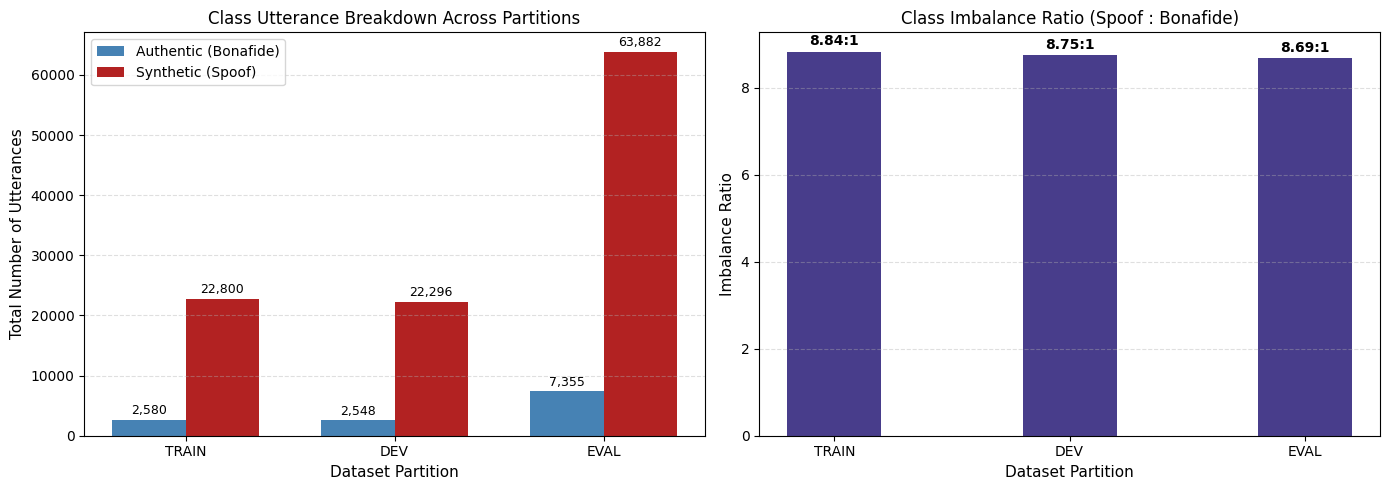

Saved Figure 01: Class distribution breakdown.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

parts = [p for p in ["train", "dev", "eval"] if len(manifest_df[manifest_df["partition"] == p]) > 0]
bon_counts = [int(((manifest_df["partition"] == p) & (manifest_df["key"] == "bonafide")).sum()) for p in parts]
spf_counts = [int(((manifest_df["partition"] == p) & (manifest_df["key"] == "spoof")).sum()) for p in parts]

x_idx = np.arange(len(parts))
b_width = 0.35

axes[0].bar(x_idx - b_width/2, bon_counts, b_width, label="Authentic (Bonafide)", color="steelblue")
axes[0].bar(x_idx + b_width/2, spf_counts, b_width, label="Synthetic (Spoof)", color="firebrick")
axes[0].set_title("Class Utterance Breakdown Across Partitions", fontsize=12)
axes[0].set_xlabel("Dataset Partition", fontsize=11)
axes[0].set_ylabel("Total Number of Utterances", fontsize=11)
axes[0].set_xticks(x_idx)
axes[0].set_xticklabels([p.upper() for p in parts], fontsize=10)
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

for i in range(len(parts)):
    axes[0].text(x_idx[i] - b_width/2, bon_counts[i] + max(spf_counts)*0.015, f"{bon_counts[i]:,}", ha="center", fontsize=9)
    axes[0].text(x_idx[i] + b_width/2, spf_counts[i] + max(spf_counts)*0.015, f"{spf_counts[i]:,}", ha="center", fontsize=9)

ratios = [spf_counts[i] / max(bon_counts[i], 1) for i in range(len(parts))]
axes[1].bar([p.upper() for p in parts], ratios, color="darkslateblue", width=0.4)
axes[1].set_title("Class Imbalance Ratio (Spoof : Bonafide)", fontsize=12)
axes[1].set_xlabel("Dataset Partition", fontsize=11)
axes[1].set_ylabel("Imbalance Ratio", fontsize=11)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

for i, r in enumerate(ratios):
    axes[1].text(i, r + 0.15, f"{r:.2f}:1", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "01_class_distribution_breakdown.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 01: Class distribution breakdown.")


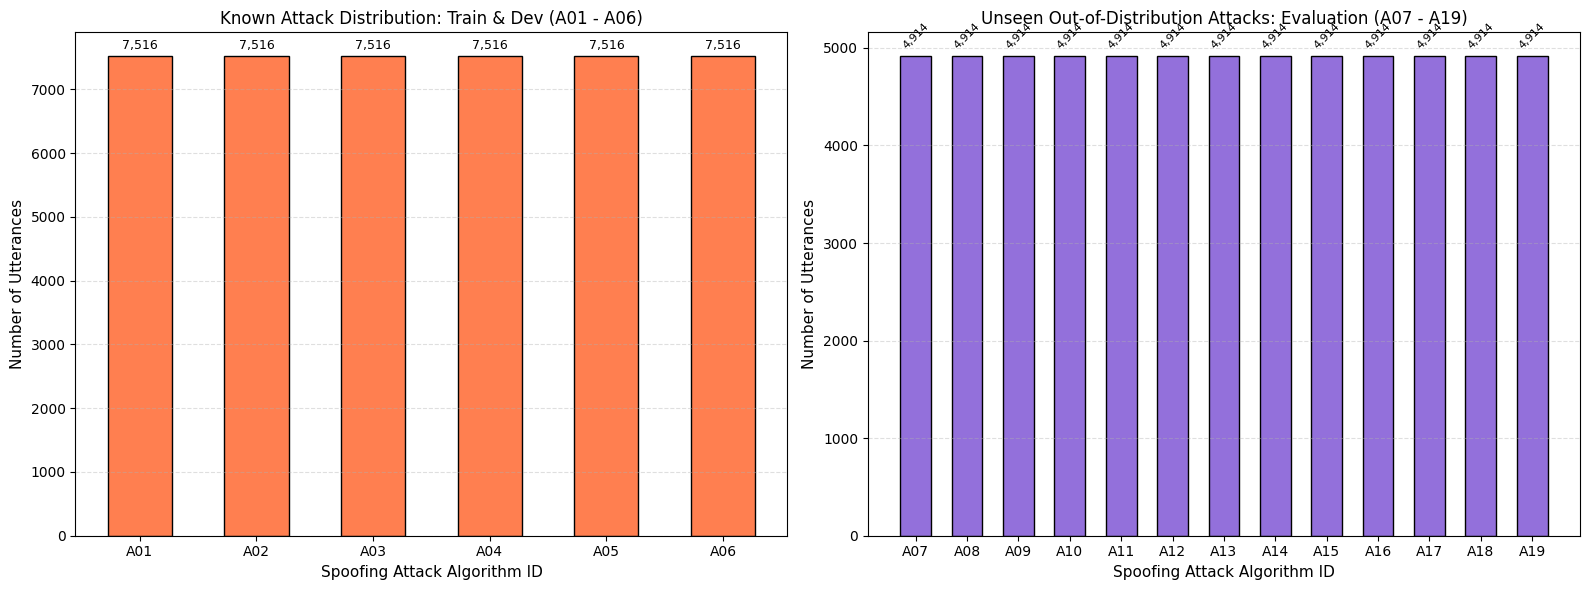

Saved Figure 02: Attack distribution analysis.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

train_dev_atks = manifest_df[manifest_df["partition"].isin(["train", "dev"]) & (manifest_df["attack_id"] != "Bonafide")]
td_counts = train_dev_atks["attack_id"].value_counts().sort_index()

eval_atks = manifest_df[(manifest_df["partition"] == "eval") & (manifest_df["attack_id"] != "Bonafide")]
eval_counts = eval_atks["attack_id"].value_counts().sort_index()

axes[0].bar(td_counts.index, td_counts.values, color="coral", edgecolor="black", width=0.55)
axes[0].set_title("Known Attack Distribution: Train & Dev (A01 - A06)", fontsize=12)
axes[0].set_xlabel("Spoofing Attack Algorithm ID", fontsize=11)
axes[0].set_ylabel("Number of Utterances", fontsize=11)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
for idx, val in enumerate(td_counts.values):
    axes[0].text(idx, val + max(td_counts.values)*0.015, f"{val:,}", ha="center", fontsize=9)

axes[1].bar(eval_counts.index, eval_counts.values, color="mediumpurple", edgecolor="black", width=0.6)
axes[1].set_title("Unseen Out-of-Distribution Attacks: Evaluation (A07 - A19)", fontsize=12)
axes[1].set_xlabel("Spoofing Attack Algorithm ID", fontsize=11)
axes[1].set_ylabel("Number of Utterances", fontsize=11)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
for idx, val in enumerate(eval_counts.values):
    axes[1].text(idx, val + max(eval_counts.values)*0.015, f"{val:,}", ha="center", fontsize=8, rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "02_attack_distribution_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 02: Attack distribution analysis.")


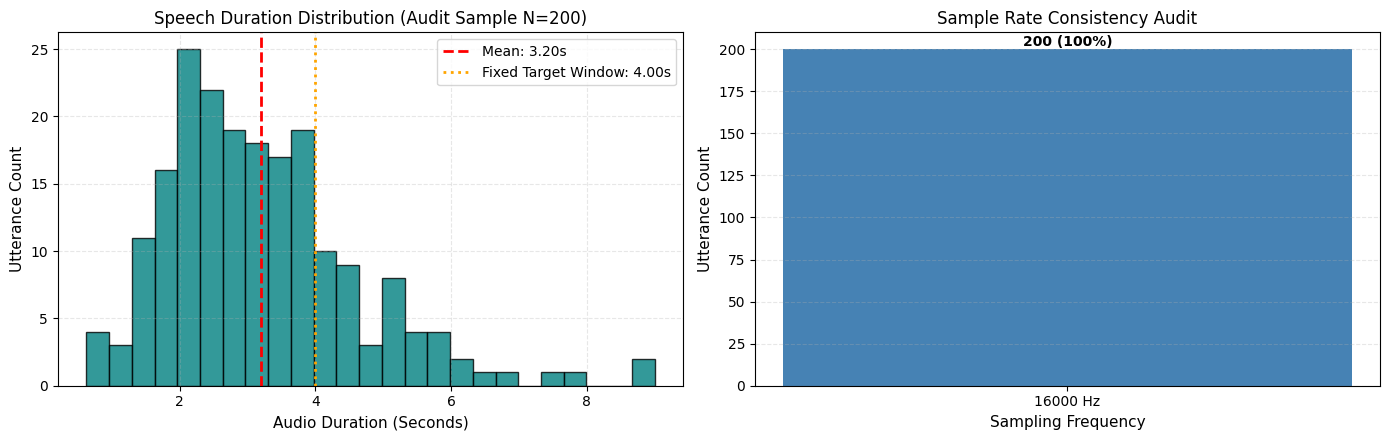

Saved Figure 03: Audio duration and sample rate audit.


In [7]:
sample_rows = manifest_df.sample(min(200, len(manifest_df)), random_state=42)
durations = []
sample_rates = []

for _, r in sample_rows.iterrows():
    fpath = r["file_path"]
    if os.path.isfile(fpath):
        try:
            info = sf.info(fpath)
            durations.append(info.duration)
            sample_rates.append(info.samplerate)
        except Exception:
            pass

durations = np.array(durations)
sample_rates = np.array(sample_rates)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(durations, bins=25, color="teal", edgecolor="black", alpha=0.8)
axes[0].axvline(np.mean(durations), color="red", linestyle="--", lw=2, label=f"Mean: {np.mean(durations):.2f}s")
axes[0].axvline(4.0, color="orange", linestyle=":", lw=2, label="Fixed Target Window: 4.00s")
axes[0].set_title("Speech Duration Distribution (Audit Sample N=200)", fontsize=12)
axes[0].set_xlabel("Audio Duration (Seconds)", fontsize=11)
axes[0].set_ylabel("Utterance Count", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.3)

sr_counts = pd.Series(sample_rates).value_counts()
axes[1].bar([f"{int(sr)} Hz" for sr in sr_counts.index], sr_counts.values, color="steelblue", width=0.3)
axes[1].set_title("Sample Rate Consistency Audit", fontsize=12)
axes[1].set_xlabel("Sampling Frequency", fontsize=11)
axes[1].set_ylabel("Utterance Count", fontsize=11)
axes[1].grid(axis="y", linestyle="--", alpha=0.3)
for i, v in enumerate(sr_counts.values):
    axes[1].text(i, v + 2, f"{v} (100%)", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "03_audio_duration_length_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 03: Audio duration and sample rate audit.")


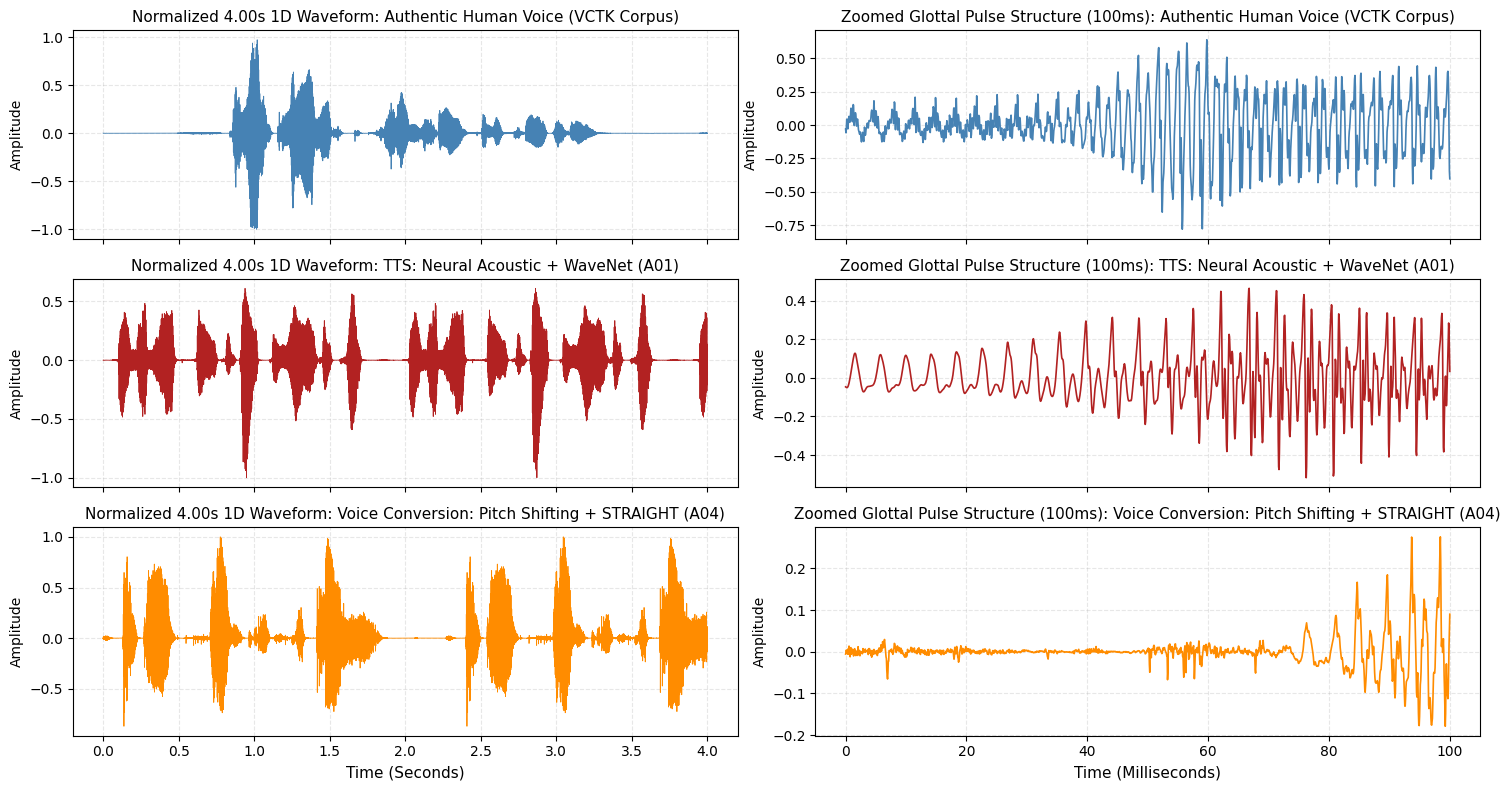

Saved Figure 04: Waveform and glottal pulse inspection.


In [8]:
def read_raw_waveform(path, target_len=64000):
    try:
        sig, sr = sf.read(path, dtype="float32")
        if sig.ndim > 1:
            sig = np.mean(sig, axis=1)
        curr_len = len(sig)
        if curr_len < target_len:
            rep = math.ceil(target_len / max(curr_len, 1))
            sig = np.tile(sig, rep)[:target_len]
        elif curr_len > target_len:
            start = (curr_len - target_len) // 2
            sig = sig[start:start + target_len]
        peak = np.max(np.abs(sig))
        if peak > 1e-6:
            sig = sig / peak
        return sig
    except Exception:
        return np.zeros(target_len, dtype=np.float32)

bon_sample_path = train_df[train_df["key"] == "bonafide"].iloc[0]["file_path"]
a01_sample_path = train_df[train_df["attack_id"] == "A01"].iloc[0]["file_path"]
a04_sample_path = train_df[train_df["attack_id"] == "A04"].iloc[0]["file_path"]

sig_bon = read_raw_waveform(bon_sample_path)
sig_a01 = read_raw_waveform(a01_sample_path)
sig_a04 = read_raw_waveform(a04_sample_path)

fig, axes = plt.subplots(3, 2, figsize=(15, 8), sharex="col")
zoom_len = 1600

demo_signals = [
    (sig_bon, "Authentic Human Voice (VCTK Corpus)", "steelblue"),
    (sig_a01, "TTS: Neural Acoustic + WaveNet (A01)", "firebrick"),
    (sig_a04, "Voice Conversion: Pitch Shifting + STRAIGHT (A04)", "darkorange")
]

for row_idx, (sig, label, col) in enumerate(demo_signals):
    t_full = np.linspace(0, 4.0, len(sig))
    axes[row_idx, 0].plot(t_full, sig, color=col, lw=0.6)
    axes[row_idx, 0].set_ylabel("Amplitude", fontsize=10)
    axes[row_idx, 0].set_title(f"Normalized 4.00s 1D Waveform: {label}", fontsize=11)
    axes[row_idx, 0].grid(True, linestyle="--", alpha=0.3)

    t_zoom = np.linspace(0, zoom_len / 16000, zoom_len)
    start_pt = int(16000 * 1.2)
    axes[row_idx, 1].plot(t_zoom * 1000, sig[start_pt:start_pt + zoom_len], color=col, lw=1.2)
    axes[row_idx, 1].set_ylabel("Amplitude", fontsize=10)
    axes[row_idx, 1].set_title(f"Zoomed Glottal Pulse Structure (100ms): {label}", fontsize=11)
    axes[row_idx, 1].grid(True, linestyle="--", alpha=0.3)

axes[2, 0].set_xlabel("Time (Seconds)", fontsize=11)
axes[2, 1].set_xlabel("Time (Milliseconds)", fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "04_waveform_time_domain_glottal_inspection.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 04: Waveform and glottal pulse inspection.")


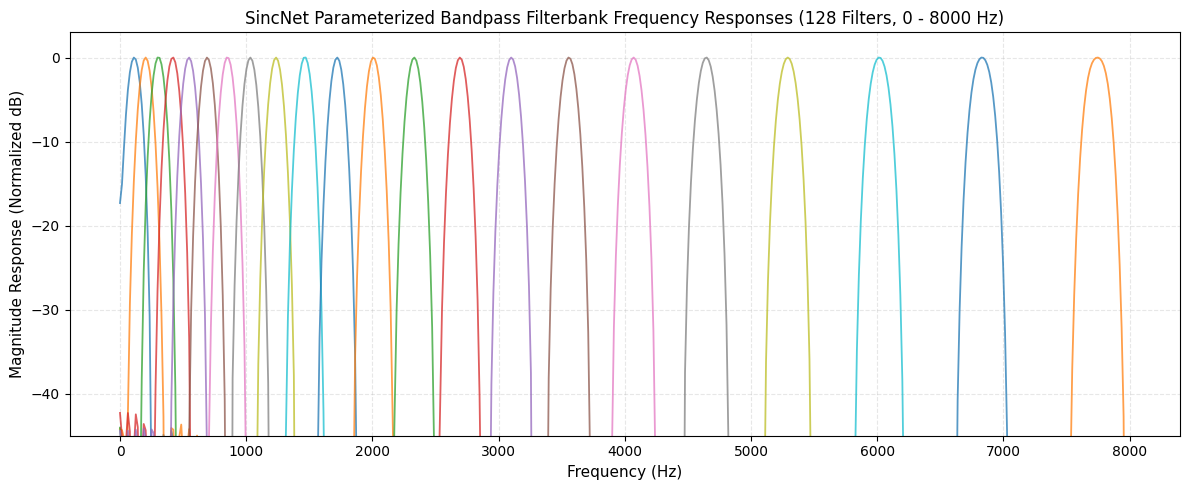

Saved Figure 05: SincNet parameterized filterbank frequency response.


In [9]:
class SincConv(nn.Module):
    @classmethod
    def to_mel(cls, hz):
        return 2595.0 * math.log10(1.0 + hz / 700.0)

    @classmethod
    def to_hz(cls, mel):
        return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

    def __init__(self, out_channels=128, kernel_size=251, sample_rate=16000, in_channels=1, min_low_hz=50, min_band_hz=50):
        super().__init__()
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sample_rate = sample_rate
        self.min_low_hz = min_low_hz
        self.min_band_hz = min_band_hz

        if kernel_size % 2 == 0:
            self.kernel_size = kernel_size + 1

        low_hz = 30.0
        high_hz = sample_rate / 2.0 - (min_low_hz + min_band_hz)

        mel_low = self.to_mel(low_hz)
        mel_high = self.to_mel(high_hz)
        mel_points = torch.linspace(mel_low, mel_high, out_channels + 1)
        hz_points = self.to_hz(mel_points)

        self.low_hz_ = nn.Parameter(hz_points[:-1].view(-1, 1))
        self.band_hz_ = nn.Parameter((hz_points[1:] - hz_points[:-1]).view(-1, 1))

        n_lin = torch.linspace(0, (self.kernel_size / 2) - 1, int(self.kernel_size / 2))
        self.window_ = 0.54 - 0.46 * torch.cos(2.0 * math.pi * n_lin / self.kernel_size)
        n_ = 2.0 * math.pi * (torch.arange(-(self.kernel_size - 1) / 2.0, 0.0).view(1, -1)) / self.sample_rate
        self.register_buffer("n_", n_)

    def get_filterbank(self):
        low = self.min_low_hz + torch.abs(self.low_hz_)
        high = torch.clamp(low + self.min_band_hz + torch.abs(self.band_hz_), self.min_low_hz, self.sample_rate / 2.0)
        band = (high - low)[:, 0]

        n_buf = self.n_.to(self.low_hz_.device)
        win_buf = self.window_.to(self.low_hz_.device)

        f_times_t_low = torch.matmul(low, n_buf)
        f_times_t_high = torch.matmul(high, n_buf)

        band_pass_left = ((torch.sin(f_times_t_high) - torch.sin(f_times_t_low)) / (n_buf / 2.0)) * win_buf
        band_pass_center = 2.0 * band.view(-1, 1)
        band_pass_right = torch.flip(band_pass_left, dims=[1])

        band_pass = torch.cat([band_pass_left, band_pass_center, band_pass_right], dim=1)
        band_pass = band_pass / (2.0 * band.view(-1, 1))
        return band_pass

    def forward(self, waveforms):
        filters = self.get_filterbank().view(self.out_channels, 1, self.kernel_size)
        return F.conv1d(waveforms, filters, stride=1, padding=self.kernel_size // 2)

demo_sinc = SincConv(out_channels=128, kernel_size=251, sample_rate=16000)
demo_filters = demo_sinc.get_filterbank().detach().cpu().numpy()

plt.figure(figsize=(12, 5))
freq_axis = np.linspace(0, 8000, 512)

for i in range(0, 128, 6):
    filt = demo_filters[i]
    fft_val = np.abs(np.fft.rfft(filt, n=1024))[:512]
    fft_db = 20 * np.log10(fft_val + 1e-6)
    fft_db = fft_db - np.max(fft_db)
    plt.plot(freq_axis, fft_db, alpha=0.75, lw=1.3)

plt.title("SincNet Parameterized Bandpass Filterbank Frequency Responses (128 Filters, 0 - 8000 Hz)", fontsize=12)
plt.xlabel("Frequency (Hz)", fontsize=11)
plt.ylabel("Magnitude Response (Normalized dB)", fontsize=11)
plt.ylim(-45, 3)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "05_sincnet_learned_filterbank_frequency_response.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 05: SincNet parameterized filterbank frequency response.")


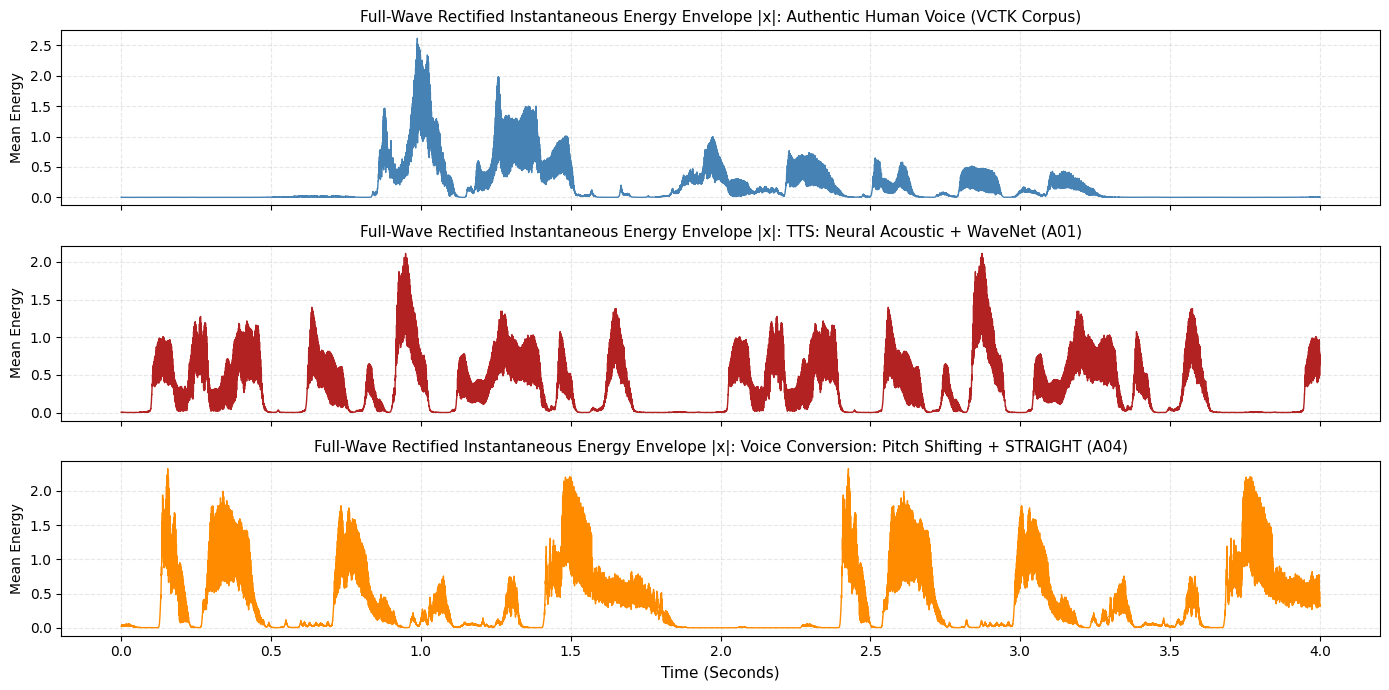

Saved Figure 06: Full-wave rectified instantaneous energy envelope detection.


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

for idx, (sig, label, col) in enumerate(demo_signals):
    t_tens = torch.from_numpy(sig).float().unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        filtered = demo_sinc(t_tens)
        envelope = torch.abs(filtered)
        energy_profile = envelope.mean(dim=1).squeeze().numpy()

    t_axis = np.linspace(0, 4.0, len(energy_profile))
    axes[idx].plot(t_axis, energy_profile, color=col, lw=1.0)
    axes[idx].set_title(f"Full-Wave Rectified Instantaneous Energy Envelope |x|: {label}", fontsize=11)
    axes[idx].set_ylabel("Mean Energy", fontsize=10)
    axes[idx].grid(True, linestyle="--", alpha=0.3)

axes[2].set_xlabel("Time (Seconds)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "06_instantaneous_energy_envelope_detection.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 06: Full-wave rectified instantaneous energy envelope detection.")


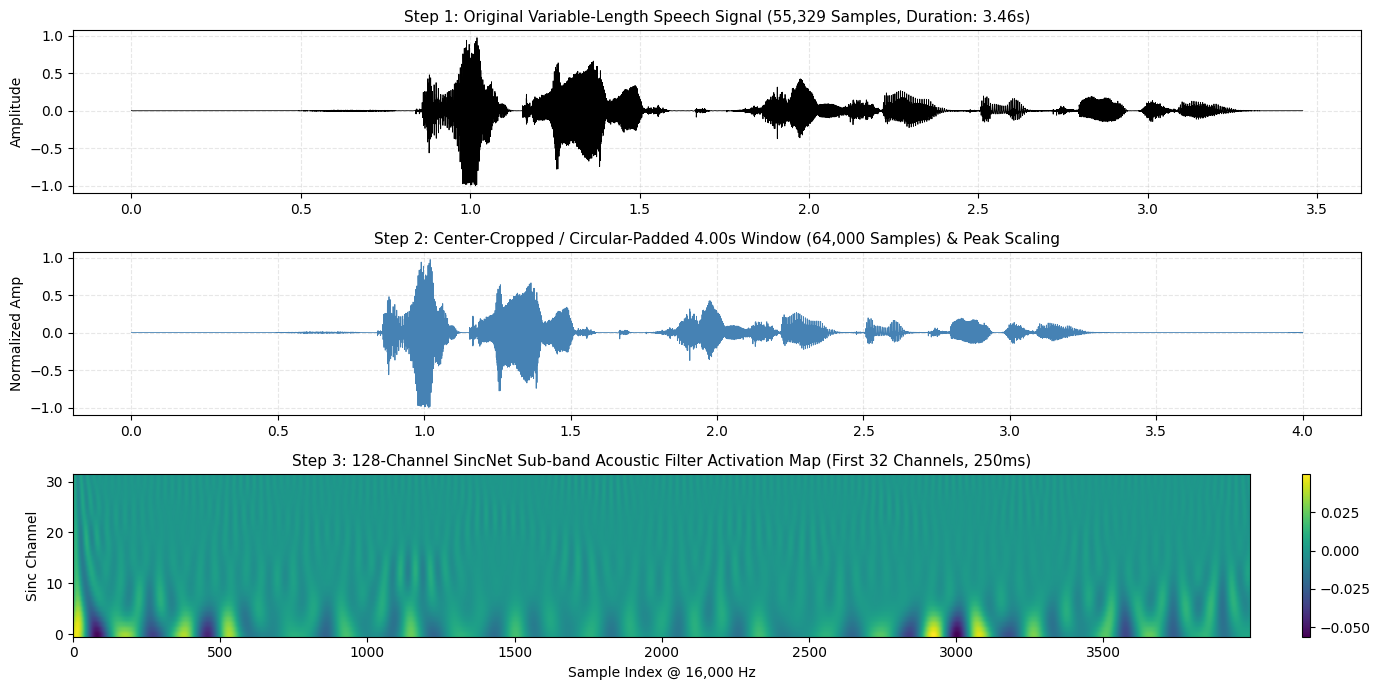

Saved Figure 07: Time-domain signal preprocessing pipeline.


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=False)

raw_demo, _ = sf.read(bon_sample_path, dtype="float32")
if raw_demo.ndim > 1:
    raw_demo = np.mean(raw_demo, axis=1)

t_raw = np.linspace(0, len(raw_demo)/16000, len(raw_demo))
axes[0].plot(t_raw, raw_demo, color="black", lw=0.6)
axes[0].set_title(f"Step 1: Original Variable-Length Speech Signal ({len(raw_demo):,} Samples, Duration: {len(raw_demo)/16000:.2f}s)", fontsize=11)
axes[0].set_ylabel("Amplitude", fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.3)

norm_demo = read_raw_waveform(bon_sample_path, target_len=64000)
t_norm = np.linspace(0, 4.0, 64000)
axes[1].plot(t_norm, norm_demo, color="steelblue", lw=0.6)
axes[1].set_title("Step 2: Center-Cropped / Circular-Padded 4.00s Window (64,000 Samples) & Peak Scaling", fontsize=11)
axes[1].set_ylabel("Normalized Amp", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.3)

t_tens = torch.from_numpy(norm_demo).float().unsqueeze(0).unsqueeze(0)
with torch.no_grad():
    sinc_out = demo_sinc(t_tens).squeeze().numpy()

im = axes[2].imshow(sinc_out[:32, :4000], origin="lower", aspect="auto", cmap="viridis")
axes[2].set_title("Step 3: 128-Channel SincNet Sub-band Acoustic Filter Activation Map (First 32 Channels, 250ms)", fontsize=11)
axes[2].set_xlabel("Sample Index @ 16,000 Hz", fontsize=10)
axes[2].set_ylabel("Sinc Channel", fontsize=10)
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "07_time_domain_signal_preprocessing_pipeline.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 07: Time-domain signal preprocessing pipeline.")


In [12]:
class RawAudioDataset(Dataset):
    def __init__(self, df, target_len=64000, is_train=False):
        self.df = df.reset_index(drop=True)
        self.target_len = target_len
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = row["file_path"]
        label = int(row["is_spoof"])

        try:
            sig, sr = sf.read(file_path, dtype="float32")
            if sig.ndim > 1:
                sig = np.mean(sig, axis=1)
        except Exception:
            sig = np.zeros(self.target_len, dtype=np.float32)

        curr_len = len(sig)
        if curr_len < self.target_len:
            repeat_factor = math.ceil(self.target_len / max(curr_len, 1))
            sig = np.tile(sig, repeat_factor)[:self.target_len]
        elif curr_len > self.target_len:
            if self.is_train:
                max_start = curr_len - self.target_len
                start = random.randint(0, max_start)
                sig = sig[start:start + self.target_len]
            else:
                start = (curr_len - self.target_len) // 2
                sig = sig[start:start + self.target_len]

        if self.is_train:
            if random.random() < 0.35:
                scale = random.uniform(0.7, 1.2)
                sig = sig * scale
            if random.random() < 0.25:
                noise_amp = random.uniform(0.001, 0.008)
                sig = sig + noise_amp * np.random.randn(len(sig)).astype(np.float32)

        peak = np.max(np.abs(sig))
        if peak > 1e-6:
            sig = sig / peak

        tensor_x = torch.from_numpy(sig).float().unsqueeze(0)
        tensor_y = torch.tensor(label, dtype=torch.long)
        return tensor_x, tensor_y

train_dataset = RawAudioDataset(train_df, is_train=True)
dev_dataset = RawAudioDataset(dev_df, is_train=False)
eval_dataset = RawAudioDataset(eval_df, is_train=False) if len(eval_df) > 0 else None

train_targets = train_df["is_spoof"].values
class_counts = np.bincount(train_targets)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = torch.FloatTensor(class_weights[train_targets])
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

batch_size = 64
num_workers = 2

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=num_workers, pin_memory=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size * 2, shuffle=False, num_workers=num_workers, pin_memory=True)
eval_loader = DataLoader(eval_dataset, batch_size=batch_size * 2, shuffle=False, num_workers=num_workers, pin_memory=True) if eval_dataset else None

print("Raw Waveform DataLoaders Formulated:")
print(f"  Train: {len(train_loader)} batches (Batch Size: {batch_size}, Weighted Balanced Sampler)")
print(f"  Dev:   {len(dev_loader)} batches (Batch Size: {batch_size * 2})")
if eval_loader:
    print(f"  Eval:  {len(eval_loader)} batches (Batch Size: {batch_size * 2}, Full 71,237 Utterances)")


Raw Waveform DataLoaders Formulated:
  Train: 397 batches (Batch Size: 64, Weighted Balanced Sampler)
  Dev:   195 batches (Batch Size: 128)
  Eval:  557 batches (Batch Size: 128, Full 71,237 Utterances)


In [13]:
class FMSBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(channels, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(2)
        return x * w

class RawResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool_size=3):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.lrelu = nn.LeakyReLU(0.2)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.fms = FMSBlock(out_ch)
        self.pool = nn.MaxPool1d(pool_size)

        if in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        res = self.shortcut(x)
        out = self.lrelu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.fms(out)
        out = self.lrelu(out + res)
        out = self.pool(out)
        return out

class RawNet2Mini(nn.Module):
    def __init__(self, num_classes=2, dropout=0.3):
        super().__init__()
        self.sinc_conv = SincConv(out_channels=128, kernel_size=251, sample_rate=16000)
        self.first_pool = nn.MaxPool1d(3)
        self.first_bn = nn.BatchNorm1d(128)
        self.lrelu = nn.LeakyReLU(0.2)

        self.block1 = RawResidualBlock(128, 128, pool_size=3)
        self.block2 = RawResidualBlock(128, 128, pool_size=3)
        self.block3 = RawResidualBlock(128, 256, pool_size=3)
        self.block4 = RawResidualBlock(256, 256, pool_size=3)
        self.block5 = RawResidualBlock(256, 512, pool_size=3)
        self.block6 = RawResidualBlock(512, 512, pool_size=3)

        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc_latent = nn.Linear(1024, 64)
        self.bn_latent = nn.BatchNorm1d(64)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(64, num_classes)

    def extract_features(self, x):
        out = self.sinc_conv(x)
        out = torch.abs(out)
        out = self.first_pool(out)
        out = self.lrelu(self.first_bn(out))
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = self.block4(out)
        out = self.block5(out)
        out = self.block6(out)
        return out

    def extract_latent(self, x):
        feat = self.extract_features(x)
        p1 = self.avg_pool(feat).squeeze(2)
        p2 = self.max_pool(feat).squeeze(2)
        pooled = torch.cat([p1, p2], dim=1)
        latent = self.lrelu(self.bn_latent(self.fc_latent(pooled)))
        return latent

    def forward(self, x):
        latent = self.extract_latent(x)
        out = self.dropout(latent)
        logits = self.classifier(out)
        return logits

model = RawNet2Mini().to(device)
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"RawNet2-Mini Instantiated. Trainable Parameters: {param_count:,}")

with torch.no_grad():
    dummy_x = torch.zeros(2, 1, 64000).to(device)
    dummy_logits = model(dummy_x)
    dummy_lat = model.extract_latent(dummy_x)
    print(f"Logits Output Shape: {dummy_logits.shape} (Expected: (2, 2))")
    print(f"Latent Output Shape: {dummy_lat.shape} (Expected: (2, 64))")


RawNet2-Mini Instantiated. Trainable Parameters: 4,566,082
Logits Output Shape: torch.Size([2, 2]) (Expected: (2, 2))
Latent Output Shape: torch.Size([2, 64]) (Expected: (2, 64))


In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none", label_smoothing=self.label_smoothing)
        p_t = torch.exp(-ce)
        alpha_t = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        loss = alpha_t * ((1.0 - p_t) ** self.gamma) * ce
        return loss.mean()

criterion = FocalLoss(alpha=0.75, gamma=2.0, label_smoothing=0.05)
print("Focal Loss criterion configured with alpha=0.75, gamma=2.0, label_smoothing=0.05.")


Focal Loss criterion configured with alpha=0.75, gamma=2.0, label_smoothing=0.05.


In [15]:
def calculate_biometrics(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1.0 - tpr
    diff = np.abs(fpr - fnr)
    idx = np.nanargmin(diff)
    eer = float((fpr[idx] + fnr[idx]) / 2.0)
    opt_threshold = float(np.clip(thresholds[idx], 0.0, 1.0))
    auc = float(roc_auc_score(y_true, y_score))

    c_miss = 1.0
    c_fa = 10.0
    p_tar = 0.05
    p_spoof = 0.90
    cm_cost = c_miss * p_tar * fnr + c_fa * p_spoof * fpr
    norm_factor = min(c_miss * p_tar, c_fa * p_spoof)
    min_tdcf = float(np.min(cm_cost) / norm_factor)

    return {
        "eer": eer,
        "optimal_threshold": opt_threshold,
        "auc": auc,
        "min_tdcf": min_tdcf,
        "fpr": fpr,
        "tpr": tpr,
        "fnr": fnr,
        "thresholds": thresholds
    }

def evaluate_network_batches(net, loader, compute_device, use_mixed_precision, log_interval=50):
    net.eval()
    prob_list = []
    target_list = []
    total_batches = len(loader)
    t_start = time.time()

    with torch.no_grad():
        for b_idx, (x_b, y_b) in enumerate(loader, 1):
            x_b = x_b.to(compute_device)
            with torch.amp.autocast(device_type=compute_device.type, enabled=use_mixed_precision):
                logits = net(x_b)
                probs = torch.softmax(logits, dim=1)[:, 1]
            prob_list.append(probs.cpu().numpy())
            target_list.append(y_b.numpy())

            if b_idx % log_interval == 0 or b_idx == total_batches:
                proc_cnt = min(b_idx * loader.batch_size, len(loader.dataset))
                elapsed = time.time() - t_start
                print(f"    [Batch {b_idx:03d}/{total_batches:03d}] Processed {proc_cnt:,} / {len(loader.dataset):,} utterances ({elapsed:.1f}s)")

    all_probs = np.concatenate(prob_list)
    all_targets = np.concatenate(target_list)
    metrics = calculate_biometrics(all_targets, all_probs)
    return metrics, all_probs, all_targets

print("Biometric evaluation engine and batch progress tracker initialized.")


Biometric evaluation engine and batch progress tracker initialized.


In [16]:
epochs = 20
lr_init = 1e-4
lr_min = 1e-6
weight_decay = 1e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=lr_init, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=lr_min)
scaler = torch.amp.GradScaler(device=device.type, enabled=use_amp)

best_model_path = os.path.join(weights_dir, "rawnet2_best.pth")
history_file = os.path.join(weights_dir, "training_history.json")

best_dev_eer = float("inf")
best_dev_auc = 0.0
best_dev_threshold = 0.5
training_history = []

print(f"Commencing RawNet2-Mini End-to-End Training ({epochs} Epochs)")
print("=" * 85)

for epoch in range(1, epochs + 1):
    t_start = time.time()
    model.train()
    running_loss = 0.0

    for x_b, y_b in train_loader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            outputs = model(x_b)
            loss = criterion(outputs, y_b)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * x_b.size(0)

    epoch_loss = running_loss / len(train_dataset)
    scheduler.step()

    dev_metrics, _, _ = evaluate_network_batches(model, dev_loader, device, use_amp, log_interval=100)
    dev_eer = dev_metrics["eer"]
    dev_auc = dev_metrics["auc"]
    dev_thresh = dev_metrics["optimal_threshold"]
    dev_tdcf = dev_metrics["min_tdcf"]

    elapsed = time.time() - t_start
    log_entry = {
        "epoch": epoch,
        "train_loss": round(epoch_loss, 5),
        "dev_eer": round(dev_eer, 5),
        "dev_auc": round(dev_auc, 5),
        "dev_min_tdcf": round(dev_tdcf, 5),
        "dev_threshold": round(dev_thresh, 5),
        "time_seconds": round(elapsed, 1)
    }
    training_history.append(log_entry)

    is_optimal = dev_eer < best_dev_eer
    if is_optimal:
        best_dev_eer = dev_eer
        best_dev_auc = dev_auc
        best_dev_threshold = dev_thresh
        torch.save({
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "eer": best_dev_eer,
            "auc": best_dev_auc,
            "threshold": best_dev_threshold,
            "architecture": "RawNet2-Mini"
        }, best_model_path)

    star = " [NEW BEST]" if is_optimal else ""
    print(f"Epoch [{epoch:02d}/{epochs:02d}] | Loss: {epoch_loss:.4f} | Dev EER: {dev_eer*100:.3f}% | Dev AUC: {dev_auc:.4f} | min t-DCF: {dev_tdcf:.4f} | Time: {elapsed:.0f}s{star}")

with open(history_file, "w", encoding="utf-8") as f:
    json.dump(training_history, f, indent=2)

print("=" * 85)
print(f"Training Complete. Optimal Dev EER: {best_dev_eer*100:.3f}% | Dev AUC: {best_dev_auc:.4f}")
print(f"Optimal Checkpoint Saved: {best_model_path}")


Commencing RawNet2-Mini End-to-End Training (20 Epochs)
    [Batch 100/195] Processed 12,800 / 24,844 utterances (78.9s)
    [Batch 195/195] Processed 24,844 / 24,844 utterances (152.9s)
Epoch [01/20] | Loss: 0.0250 | Dev EER: 5.457% | Dev AUC: 0.9890 | min t-DCF: 0.5609 | Time: 472s [NEW BEST]
    [Batch 100/195] Processed 12,800 / 24,844 utterances (77.5s)
    [Batch 195/195] Processed 24,844 / 24,844 utterances (149.6s)
Epoch [02/20] | Loss: 0.0061 | Dev EER: 3.111% | Dev AUC: 0.9954 | min t-DCF: 0.2892 | Time: 471s [NEW BEST]
    [Batch 100/195] Processed 12,800 / 24,844 utterances (77.7s)
    [Batch 195/195] Processed 24,844 / 24,844 utterances (149.8s)
Epoch [03/20] | Loss: 0.0039 | Dev EER: 2.865% | Dev AUC: 0.9962 | min t-DCF: 0.3780 | Time: 471s [NEW BEST]
    [Batch 100/195] Processed 12,800 / 24,844 utterances (77.3s)
    [Batch 195/195] Processed 24,844 / 24,844 utterances (149.5s)
Epoch [04/20] | Loss: 0.0026 | Dev EER: 2.012% | Dev AUC: 0.9983 | min t-DCF: 0.1986 | Time: 

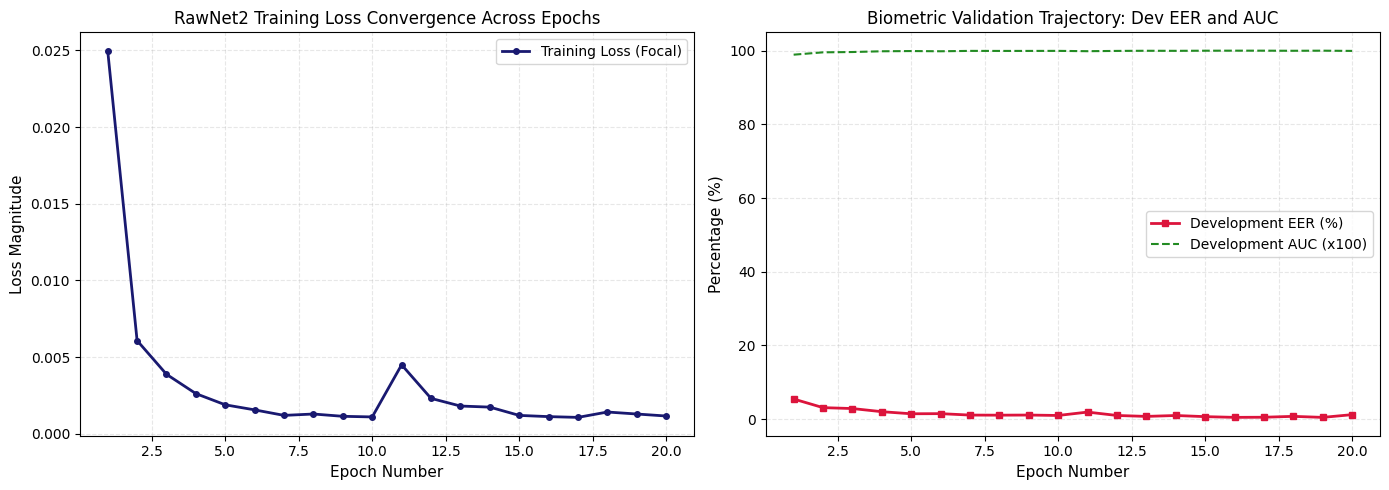

Saved Figure 08: Training loss and biometric validation trajectory.


In [17]:
epochs_x = [e["epoch"] for e in training_history]
losses_y = [e["train_loss"] for e in training_history]
eers_y = [e["dev_eer"] * 100 for e in training_history]
aucs_y = [e["dev_auc"] for e in training_history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_x, losses_y, color="midnightblue", lw=2, marker="o", markersize=4, label="Training Loss (Focal)")
axes[0].set_title("RawNet2 Training Loss Convergence Across Epochs", fontsize=12)
axes[0].set_xlabel("Epoch Number", fontsize=11)
axes[0].set_ylabel("Loss Magnitude", fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.3)
axes[0].legend(fontsize=10)

axes[1].plot(epochs_x, eers_y, color="crimson", lw=2, marker="s", markersize=4, label="Development EER (%)")
axes[1].plot(epochs_x, [a * 100 for a in aucs_y], color="forestgreen", lw=1.5, linestyle="--", label="Development AUC (x100)")
axes[1].set_title("Biometric Validation Trajectory: Dev EER and AUC", fontsize=12)
axes[1].set_xlabel("Epoch Number", fontsize=11)
axes[1].set_ylabel("Percentage (%)", fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "08_training_loss_and_dev_eer_trajectories.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 08: Training loss and biometric validation trajectory.")


In [18]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["state_dict"])
model.eval()
print(f"Loaded optimal checkpoint from epoch {checkpoint['epoch']} with Dev EER: {checkpoint['eer']*100:.3f}%")

print("Validating Development Partition with Loaded Optimal Checkpoint...")
dev_metrics, dev_scores, dev_targets = evaluate_network_batches(model, dev_loader, device, use_amp, log_interval=50)
optimal_threshold = dev_metrics["optimal_threshold"]

print("")
print("Executing Full-Scale Batch Inference on ASVspoof 2019 Evaluation Partition...")
print(f"Total Target Evaluation Utterances: {len(eval_df):,}")
t_eval_start = time.time()

eval_metrics, eval_scores, eval_targets = evaluate_network_batches(model, eval_loader, device, use_amp, log_interval=50)
t_eval_elapsed = time.time() - t_eval_start

print(f"Evaluation Partition Inference Completed in {t_eval_elapsed:.1f}s ({len(eval_df)/max(t_eval_elapsed, 1):.0f} utterances/sec)")
print("")
print("=" * 70)
print("RAWNET2-MINI COMPREHENSIVE BIOMETRIC PERFORMANCE BENCHMARK")
print("=" * 70)
print("Development Partition (Known Attacks A01 - A06):")
print(f"  Equal Error Rate (EER):      {dev_metrics['eer']*100:.3f}%")
print(f"  Normalized min t-DCF:        {dev_metrics['min_tdcf']:.4f}")
print(f"  Area Under ROC Curve (AUC):  {dev_metrics['auc']:.4f}")
print(f"  Calibrated Decision Thresh:  {optimal_threshold:.4f}")
print("")
print("Evaluation Partition (Unseen Out-of-Distribution Attacks A07 - A19):")
print(f"  Equal Error Rate (EER):      {eval_metrics['eer']*100:.3f}%")
print(f"  Normalized min t-DCF:        {eval_metrics['min_tdcf']:.4f}")
print(f"  Area Under ROC Curve (AUC):  {eval_metrics['auc']:.4f}")
print("=" * 70)


Loaded optimal checkpoint from epoch 19 with Dev EER: 0.466%
Validating Development Partition with Loaded Optimal Checkpoint...
    [Batch 050/195] Processed 6,400 / 24,844 utterances (39.1s)
    [Batch 100/195] Processed 12,800 / 24,844 utterances (77.4s)
    [Batch 150/195] Processed 19,200 / 24,844 utterances (115.7s)
    [Batch 195/195] Processed 24,844 / 24,844 utterances (149.4s)

Executing Full-Scale Batch Inference on ASVspoof 2019 Evaluation Partition...
Total Target Evaluation Utterances: 71,237
    [Batch 050/557] Processed 6,400 / 71,237 utterances (40.0s)
    [Batch 100/557] Processed 12,800 / 71,237 utterances (92.1s)
    [Batch 150/557] Processed 19,200 / 71,237 utterances (159.3s)
    [Batch 200/557] Processed 25,600 / 71,237 utterances (206.5s)
    [Batch 250/557] Processed 32,000 / 71,237 utterances (248.3s)
    [Batch 300/557] Processed 38,400 / 71,237 utterances (287.4s)
    [Batch 350/557] Processed 44,800 / 71,237 utterances (325.8s)
    [Batch 400/557] Processed 

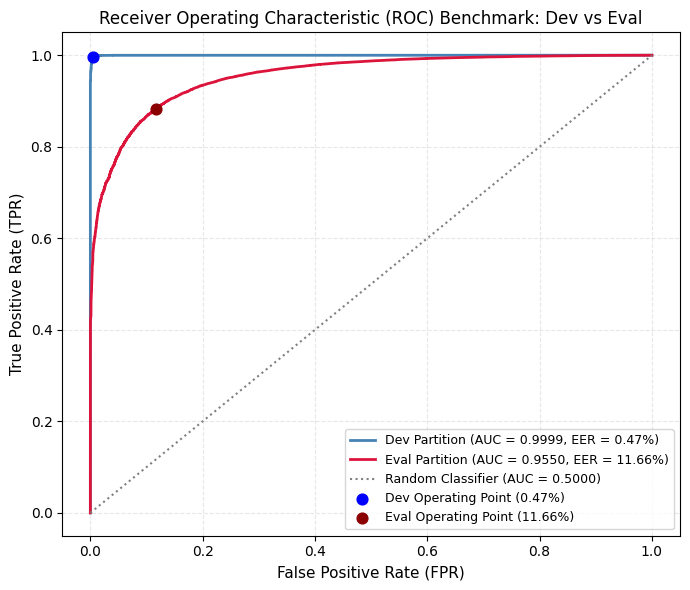

Saved Figure 09: ROC curves (Dev vs Eval).


In [19]:
plt.figure(figsize=(7, 6))
plt.plot(dev_metrics["fpr"], dev_metrics["tpr"], color="steelblue", lw=2, label=f"Dev Partition (AUC = {dev_metrics['auc']:.4f}, EER = {dev_metrics['eer']*100:.2f}%)")
plt.plot(eval_metrics["fpr"], eval_metrics["tpr"], color="crimson", lw=2, label=f"Eval Partition (AUC = {eval_metrics['auc']:.4f}, EER = {eval_metrics['eer']*100:.2f}%)")
plt.plot([0, 1], [0, 1], color="gray", linestyle=":", label="Random Classifier (AUC = 0.5000)")
plt.scatter([dev_metrics["eer"]], [1 - dev_metrics["eer"]], color="blue", s=60, zorder=5, label=f"Dev Operating Point ({dev_metrics['eer']*100:.2f}%)")
plt.scatter([eval_metrics["eer"]], [1 - eval_metrics["eer"]], color="darkred", s=60, zorder=5, label=f"Eval Operating Point ({eval_metrics['eer']*100:.2f}%)")

plt.title("Receiver Operating Characteristic (ROC) Benchmark: Dev vs Eval", fontsize=12)
plt.xlabel("False Positive Rate (FPR)", fontsize=11)
plt.ylabel("True Positive Rate (TPR)", fontsize=11)
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "09_receiver_operating_characteristic_roc.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 09: ROC curves (Dev vs Eval).")


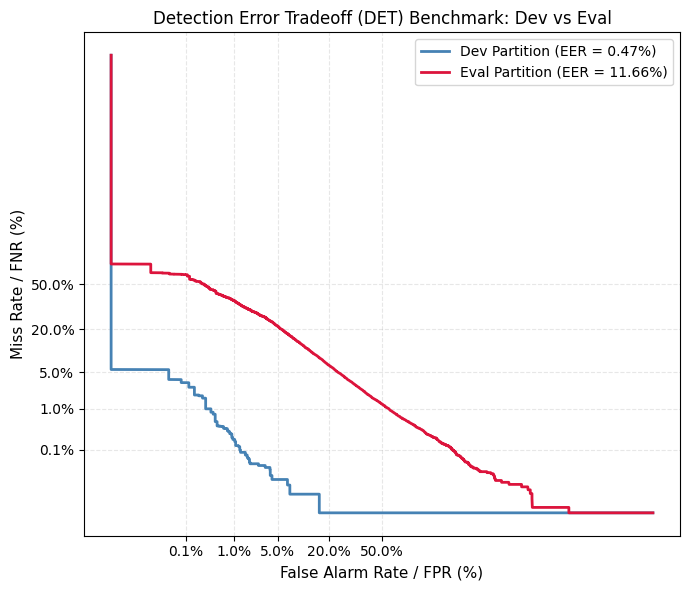

Saved Figure 10: DET curves (Dev vs Eval).


In [20]:
from scipy.stats import norm

def plot_det(fpr, fnr, label, color, ax):
    fpr_clip = np.clip(fpr, 1e-5, 1 - 1e-5)
    fnr_clip = np.clip(fnr, 1e-5, 1 - 1e-5)
    ax.plot(norm.ppf(fpr_clip), norm.ppf(fnr_clip), label=label, color=color, lw=2)

fig, ax = plt.subplots(figsize=(7, 6))
plot_det(dev_metrics["fpr"], dev_metrics["fnr"], f"Dev Partition (EER = {dev_metrics['eer']*100:.2f}%)", "steelblue", ax)
plot_det(eval_metrics["fpr"], eval_metrics["fnr"], f"Eval Partition (EER = {eval_metrics['eer']*100:.2f}%)", "crimson", ax)

ticks = [0.001, 0.01, 0.05, 0.20, 0.50]
tick_locs = norm.ppf(ticks)
tick_labels = [f"{t*100:.1f}%" for t in ticks]
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_locs)
ax.set_yticklabels(tick_labels)

ax.set_title("Detection Error Tradeoff (DET) Benchmark: Dev vs Eval", fontsize=12)
ax.set_xlabel("False Alarm Rate / FPR (%)", fontsize=11)
ax.set_ylabel("Miss Rate / FNR (%)", fontsize=11)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "10_detection_error_tradeoff_det.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 10: DET curves (Dev vs Eval).")


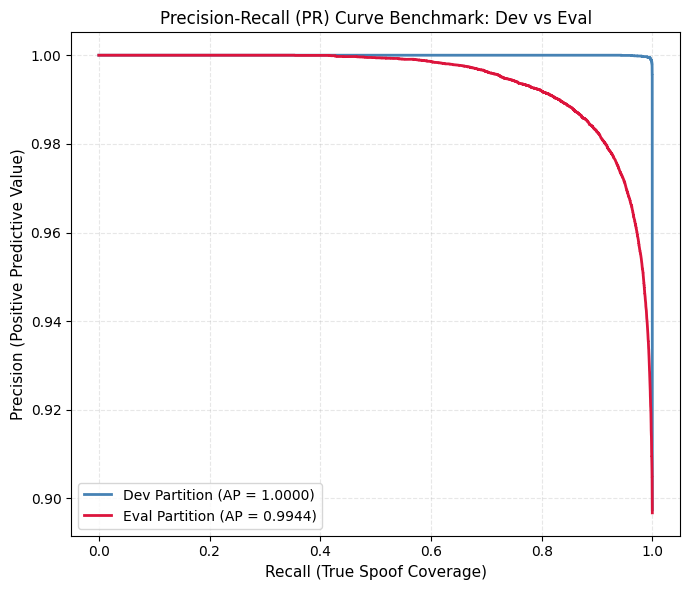

Saved Figure 11: Precision-Recall curves (Dev vs Eval).


In [21]:
prec_dev, rec_dev, _ = precision_recall_curve(dev_targets, dev_scores)
prec_eval, rec_eval, _ = precision_recall_curve(eval_targets, eval_scores)
ap_dev = average_precision_score(dev_targets, dev_scores)
ap_eval = average_precision_score(eval_targets, eval_scores)

plt.figure(figsize=(7, 6))
plt.plot(rec_dev, prec_dev, color="steelblue", lw=2, label=f"Dev Partition (AP = {ap_dev:.4f})")
plt.plot(rec_eval, prec_eval, color="crimson", lw=2, label=f"Eval Partition (AP = {ap_eval:.4f})")
plt.title("Precision-Recall (PR) Curve Benchmark: Dev vs Eval", fontsize=12)
plt.xlabel("Recall (True Spoof Coverage)", fontsize=11)
plt.ylabel("Precision (Positive Predictive Value)", fontsize=11)
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "11_precision_recall_curves.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 11: Precision-Recall curves (Dev vs Eval).")


Evaluation Confusion Matrix Performance:
  True Negatives (Authentic Correct):    7,316 (99.47%)
  False Positives (Authentic Misclassed): 39 (0.53%)
  False Negatives (Spoof Undetected):    27,061 (42.36%)
  True Positives (Spoof Detected):       36,821 (57.64%)
  Overall Evaluation Accuracy:           61.96%
  Overall Evaluation F1-Score:           0.7310


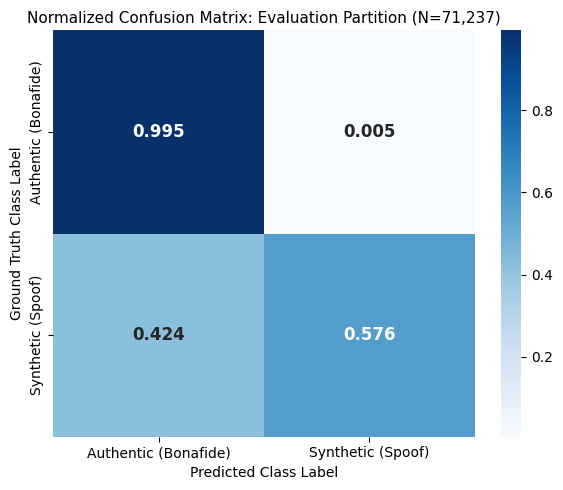

Saved Figure 12: Normalized confusion matrix on the Evaluation partition.


In [22]:
eval_preds_binary = (eval_scores >= optimal_threshold).astype(int)
cm = confusion_matrix(eval_targets, eval_preds_binary)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues", cbar=True,
            xticklabels=["Authentic (Bonafide)", "Synthetic (Spoof)"],
            yticklabels=["Authentic (Bonafide)", "Synthetic (Spoof)"],
            annot_kws={"size": 12, "weight": "bold"})
plt.title(f"Normalized Confusion Matrix: Evaluation Partition (N={len(eval_targets):,})", fontsize=11)
plt.xlabel("Predicted Class Label", fontsize=10)
plt.ylabel("Ground Truth Class Label", fontsize=10)

tn, fp, fn, tp = cm.ravel()
acc_eval = (tp + tn) / len(eval_targets)
prec_eval_val = tp / max(tp + fp, 1)
rec_eval_val = tp / max(tp + fn, 1)
f1_eval_val = 2 * (prec_eval_val * rec_eval_val) / max(prec_eval_val + rec_eval_val, 1e-6)

print("Evaluation Confusion Matrix Performance:")
print(f"  True Negatives (Authentic Correct):    {tn:,} ({cm_norm[0,0]*100:.2f}%)")
print(f"  False Positives (Authentic Misclassed): {fp:,} ({cm_norm[0,1]*100:.2f}%)")
print(f"  False Negatives (Spoof Undetected):    {fn:,} ({cm_norm[1,0]*100:.2f}%)")
print(f"  True Positives (Spoof Detected):       {tp:,} ({cm_norm[1,1]*100:.2f}%)")
print(f"  Overall Evaluation Accuracy:           {acc_eval*100:.2f}%")
print(f"  Overall Evaluation F1-Score:           {f1_eval_val:.4f}")

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "12_normalized_confusion_matrix_eval.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 12: Normalized confusion matrix on the Evaluation partition.")


Attack ID Partition      Category                         Synthesis Technology  Total Utterances  Detection Accuracy (%)  Mean Spoof Score
 Bonafide      Eval  Human Speech           VCTK Authentic Multi-Speaker Audio              7355                   99.47            0.0936
      A07      Eval Unseen (Eval)    TTS: Neural Acoustic + Waveform Filtering              4914                   99.98            0.9853
      A08      Eval Unseen (Eval)    TTS: Neural Acoustic + Spectral Filtering              4914                   99.88            0.9796
      A09      Eval Unseen (Eval)                      TTS: Poly-Phase Vocoder              4914                   98.35            0.9700
      A10      Eval Unseen (Eval) TTS: Autoregressive Neural Vocoder (WaveNet)              4914                   31.38            0.6231
      A11      Eval Unseen (Eval)   TTS: Non-Autoregressive Waveform Synthesis              4914                   45.79            0.7235
      A12      Eval Unseen 

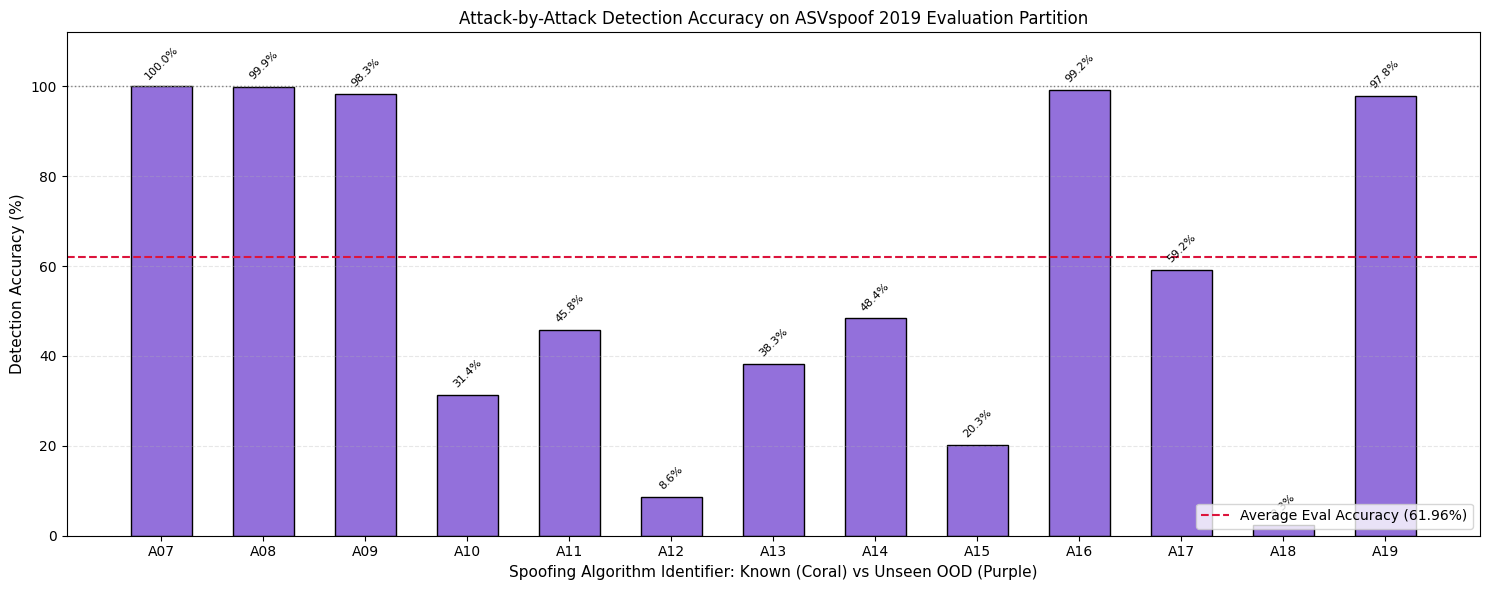

Saved Figure 13: Granular attack-by-attack detection accuracy bar chart.


In [23]:
eval_df_scored = eval_df.copy()
eval_df_scored["spoof_score"] = eval_scores
eval_df_scored["pred_label"] = eval_preds_binary

dev_df_scored = dev_df.copy()
dev_df_scored["spoof_score"] = dev_scores
dev_preds_binary = (dev_scores >= optimal_threshold).astype(int)
dev_df_scored["pred_label"] = dev_preds_binary

attack_tech_mapping = {
    "A01": ("Known (Dev)", "TTS: Neural Acoustic (AR RNN) + WaveNet"),
    "A02": ("Known (Dev)", "TTS: Neural Acoustic (AR RNN) + WORLD"),
    "A03": ("Known (Dev)", "TTS: Concatenative Unit Selection"),
    "A04": ("Known (Dev & Eval)", "VC: Formant / Pitch Shifting + STRAIGHT"),
    "A05": ("Known (Dev)", "VC: Variational Autoencoder (VAE)"),
    "A06": ("Known (Dev & Eval)", "VC: Transfer Function Regression + WORLD"),
    "A07": ("Unseen (Eval)", "TTS: Neural Acoustic + Waveform Filtering"),
    "A08": ("Unseen (Eval)", "TTS: Neural Acoustic + Spectral Filtering"),
    "A09": ("Unseen (Eval)", "TTS: Poly-Phase Vocoder"),
    "A10": ("Unseen (Eval)", "TTS: Autoregressive Neural Vocoder (WaveNet)"),
    "A11": ("Unseen (Eval)", "TTS: Non-Autoregressive Waveform Synthesis"),
    "A12": ("Unseen (Eval)", "TTS: Neural Source-Filter (NSF)"),
    "A13": ("Unseen (Eval)", "VC: Differential Formant Synthesis"),
    "A14": ("Unseen (Eval)", "VC: Direct Waveform Modification"),
    "A15": ("Unseen (Eval)", "VC: Adaptive Waveform Filtering"),
    "A16": ("Unseen (Eval)", "VC: Spectral Envelope Transformation"),
    "A17": ("Unseen (Eval)", "VC: High-Order Non-Linear Phase Mapping"),
    "A18": ("Unseen (Eval)", "VC: Formant-Preserving Pitch Synchronous"),
    "A19": ("Unseen (Eval)", "VC: Multi-Speaker Variational Transfer")
}

breakdown_records = []

bon_sub = eval_df_scored[eval_df_scored["key"] == "bonafide"]
if len(bon_sub) > 0:
    bon_corr = int((bon_sub["pred_label"] == 0).sum())
    breakdown_records.append({
        "Attack ID": "Bonafide",
        "Partition": "Eval",
        "Category": "Human Speech",
        "Synthesis Technology": "VCTK Authentic Multi-Speaker Audio",
        "Total Utterances": len(bon_sub),
        "Detection Accuracy (%)": round(bon_corr / len(bon_sub) * 100, 2),
        "Mean Spoof Score": round(float(bon_sub["spoof_score"].mean()), 4)
    })

eval_attack_ids = sorted([a for a in eval_df_scored["attack_id"].unique() if a != "Bonafide"])
for atk in eval_attack_ids:
    atk_sub = eval_df_scored[eval_df_scored["attack_id"] == atk]
    corr = int((atk_sub["pred_label"] == 1).sum())
    cat, tech = attack_tech_mapping.get(atk, ("Unseen (Eval)", "Unspecified Generative Model"))
    breakdown_records.append({
        "Attack ID": atk,
        "Partition": "Eval",
        "Category": cat,
        "Synthesis Technology": tech,
        "Total Utterances": len(atk_sub),
        "Detection Accuracy (%)": round(corr / len(atk_sub) * 100, 2),
        "Mean Spoof Score": round(float(atk_sub["spoof_score"].mean()), 4)
    })

dev_only_atks = ["A01", "A02", "A03", "A05"]
for atk in dev_only_atks:
    sub = dev_df_scored[dev_df_scored["attack_id"] == atk]
    if len(sub) > 0:
        corr = int((sub["pred_label"] == 1).sum())
        cat, tech = attack_tech_mapping.get(atk, ("Known (Dev)", "Dev Generative Model"))
        breakdown_records.append({
            "Attack ID": atk,
            "Partition": "Dev",
            "Category": cat,
            "Synthesis Technology": tech,
            "Total Utterances": len(sub),
            "Detection Accuracy (%)": round(corr / len(sub) * 100, 2),
            "Mean Spoof Score": round(float(sub["spoof_score"].mean()), 4)
        })

breakdown_df = pd.DataFrame(breakdown_records)
print(breakdown_df.to_string(index=False))

csv_out_path = "/kaggle/working/attack_vulnerability_breakdown.csv"
breakdown_df.to_csv(csv_out_path, index=False)
print(f"Exported Attack Breakdown Table to {csv_out_path}")

eval_plot_records = [r for r in breakdown_records if r["Partition"] == "Eval" and r["Attack ID"] != "Bonafide"]
eval_plot_df = pd.DataFrame(eval_plot_records).sort_values("Attack ID")

plt.figure(figsize=(15, 6))
bar_colors = ["coral" if "Known" in cat else "mediumpurple" for cat in eval_plot_df["Category"]]
bars = plt.bar(eval_plot_df["Attack ID"], eval_plot_df["Detection Accuracy (%)"], color=bar_colors, edgecolor="black", width=0.6)
plt.axhline(100.0, color="gray", linestyle=":", lw=1)
plt.axhline(acc_eval * 100, color="crimson", linestyle="--", lw=1.5, label=f"Average Eval Accuracy ({acc_eval*100:.2f}%)")

plt.title("Attack-by-Attack Detection Accuracy on ASVspoof 2019 Evaluation Partition", fontsize=12)
plt.xlabel("Spoofing Algorithm Identifier: Known (Coral) vs Unseen OOD (Purple)", fontsize=11)
plt.ylabel("Detection Accuracy (%)", fontsize=11)
plt.ylim(0, 112)
plt.legend(loc="lower right", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, h + 1.2, f"{h:.1f}%", ha="center", va="bottom", fontsize=8, rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "13_attack_by_attack_accuracy_barchart.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 13: Granular attack-by-attack detection accuracy bar chart.")


Extracted 64-Dimensional Latent Matrix: (700, 64)


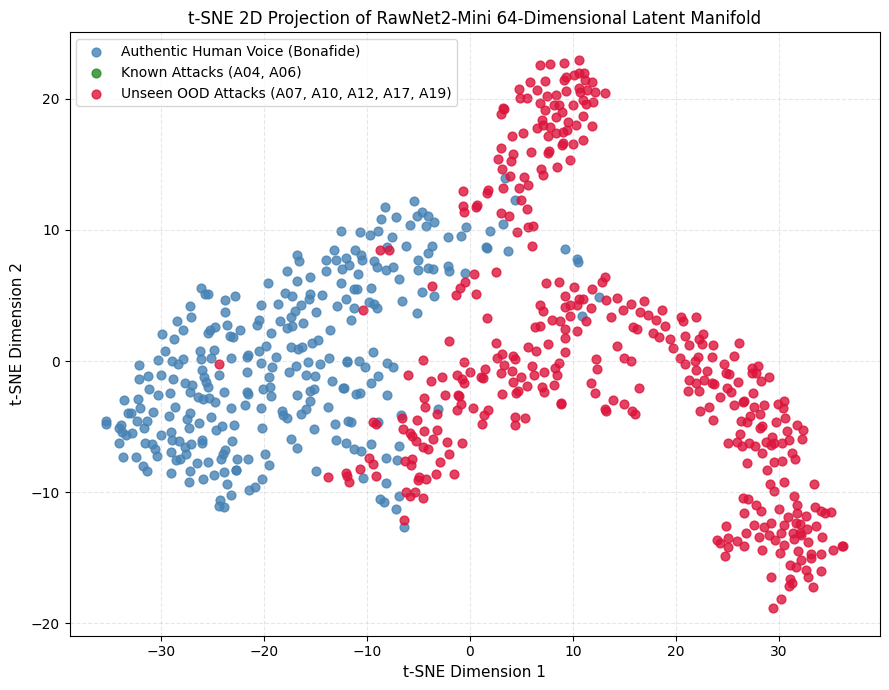

Saved Figure 14: t-SNE 2D latent manifold clustering.


In [24]:
bon_tsne = eval_df_scored[eval_df_scored["key"] == "bonafide"].sample(min(300, len(eval_df_scored[eval_df_scored["key"] == "bonafide"])), random_state=42)
known_tsne = eval_df_scored[eval_df_scored["attack_id"].isin(["A04", "A06"])].sample(min(300, len(eval_df_scored[eval_df_scored["attack_id"].isin(["A04", "A06"])])), random_state=42)
unseen_tsne = eval_df_scored[eval_df_scored["attack_id"].isin(["A07", "A10", "A12", "A17", "A19"])].sample(min(400, len(eval_df_scored[eval_df_scored["attack_id"].isin(["A07", "A10", "A12", "A17", "A19"])])), random_state=42)

tsne_manifest = pd.concat([bon_tsne, known_tsne, unseen_tsne]).reset_index(drop=True)
tsne_dataset = RawAudioDataset(tsne_manifest, is_train=False)
tsne_loader = DataLoader(tsne_dataset, batch_size=64, shuffle=False)

latents_list = []
model.eval()
with torch.no_grad():
    for x_b, _ in tsne_loader:
        x_b = x_b.to(device)
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            lat = model.extract_latent(x_b)
        latents_list.append(lat.cpu().numpy())

latent_matrix = np.concatenate(latents_list)
print(f"Extracted 64-Dimensional Latent Matrix: {latent_matrix.shape}")

tsne_model = TSNE(n_components=2, perplexity=35, random_state=42, n_iter=1000)
coords_2d = tsne_model.fit_transform(latent_matrix)

plt.figure(figsize=(9, 7))
is_bon = tsne_manifest["key"] == "bonafide"
is_known = tsne_manifest["attack_id"].isin(["A04", "A06"])
is_unseen = ~is_bon & ~is_known

plt.scatter(coords_2d[is_bon, 0], coords_2d[is_bon, 1], color="steelblue", alpha=0.8, s=40, label="Authentic Human Voice (Bonafide)")
plt.scatter(coords_2d[is_known, 0], coords_2d[is_known, 1], color="forestgreen", alpha=0.8, s=40, label="Known Attacks (A04, A06)")
plt.scatter(coords_2d[is_unseen, 0], coords_2d[is_unseen, 1], color="crimson", alpha=0.8, s=40, label="Unseen OOD Attacks (A07, A10, A12, A17, A19)")

plt.title("t-SNE 2D Projection of RawNet2-Mini 64-Dimensional Latent Manifold", fontsize=12)
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)
plt.legend(loc="best", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "14_tsne_latent_manifold_clusters.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 14: t-SNE 2D latent manifold clustering.")


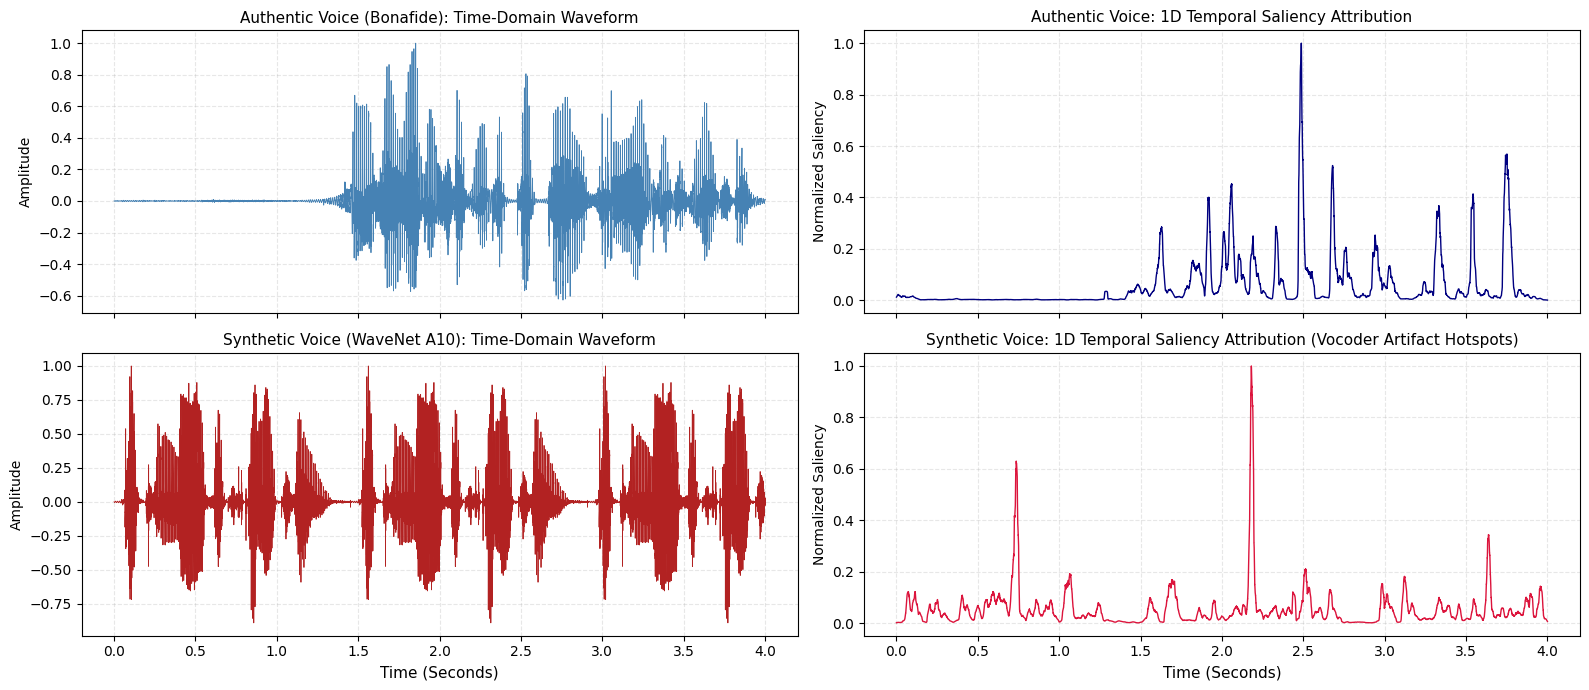

Saved Figure 15: 1D temporal saliency gradient attribution.


In [25]:
def compute_input_saliency(net, raw_tensor, target_class=1):
    net.eval()
    net.zero_grad()
    inp = raw_tensor.clone().detach().to(device)
    inp.requires_grad = True

    with torch.enable_grad():
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = net(inp)
            score = logits[0, target_class]
        score.backward()

    grads = inp.grad.squeeze().abs().cpu().numpy()
    kernel_size = 320
    kernel = np.ones(kernel_size) / kernel_size
    smoothed_saliency = np.convolve(grads, kernel, mode="same")
    smoothed_saliency = smoothed_saliency / (np.max(smoothed_saliency) + 1e-8)
    return smoothed_saliency

bon_demo_file = eval_df_scored[eval_df_scored["key"] == "bonafide"].iloc[0]["file_path"]
spf_demo_file = eval_df_scored[eval_df_scored["attack_id"] == "A10"].iloc[0]["file_path"]

sig_bon_demo = read_raw_waveform(bon_demo_file)
sig_spf_demo = read_raw_waveform(spf_demo_file)

tens_bon = torch.from_numpy(sig_bon_demo).float().unsqueeze(0).unsqueeze(0)
tens_spf = torch.from_numpy(sig_spf_demo).float().unsqueeze(0).unsqueeze(0)

saliency_bon = compute_input_saliency(model, tens_bon, target_class=0)
saliency_spf = compute_input_saliency(model, tens_spf, target_class=1)

fig, axes = plt.subplots(2, 2, figsize=(16, 7), sharex=True)
t_axis = np.linspace(0, 4.0, 64000)

axes[0, 0].plot(t_axis, sig_bon_demo, color="steelblue", lw=0.6)
axes[0, 0].set_title("Authentic Voice (Bonafide): Time-Domain Waveform", fontsize=11)
axes[0, 0].set_ylabel("Amplitude", fontsize=10)
axes[0, 0].grid(True, linestyle="--", alpha=0.3)

axes[0, 1].plot(t_axis, saliency_bon, color="navy", lw=1.0)
axes[0, 1].set_title("Authentic Voice: 1D Temporal Saliency Attribution", fontsize=11)
axes[0, 1].set_ylabel("Normalized Saliency", fontsize=10)
axes[0, 1].grid(True, linestyle="--", alpha=0.3)

axes[1, 0].plot(t_axis, sig_spf_demo, color="firebrick", lw=0.6)
axes[1, 0].set_title("Synthetic Voice (WaveNet A10): Time-Domain Waveform", fontsize=11)
axes[1, 0].set_ylabel("Amplitude", fontsize=10)
axes[1, 0].set_xlabel("Time (Seconds)", fontsize=11)
axes[1, 0].grid(True, linestyle="--", alpha=0.3)

axes[1, 1].plot(t_axis, saliency_spf, color="crimson", lw=1.0)
axes[1, 1].set_title("Synthetic Voice: 1D Temporal Saliency Attribution (Vocoder Artifact Hotspots)", fontsize=11)
axes[1, 1].set_ylabel("Normalized Saliency", fontsize=10)
axes[1, 1].set_xlabel("Time (Seconds)", fontsize=11)
axes[1, 1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "15_temporal_saliency_gradient_attribution.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 15: 1D temporal saliency gradient attribution.")


Live File-Level Biometric Inference Demonstration:

--- Test Sample 1: Ground Truth Authentic ---
{
  "file_name": "LA_E_4581379.flac",
  "decision": "BONAFIDE (AUTHENTIC HUMAN VOICE)",
  "spoof_probability": 0.70457,
  "confidence": "29.54%",
  "operating_threshold": 0.8197
}

--- Test Sample 2: Ground Truth Deepfake (A12 Neural Source-Filter) ---
{
  "file_name": "LA_E_8806575.flac",
  "decision": "BONAFIDE (AUTHENTIC HUMAN VOICE)",
  "spoof_probability": 0.1417,
  "confidence": "85.83%",
  "operating_threshold": 0.8197
}


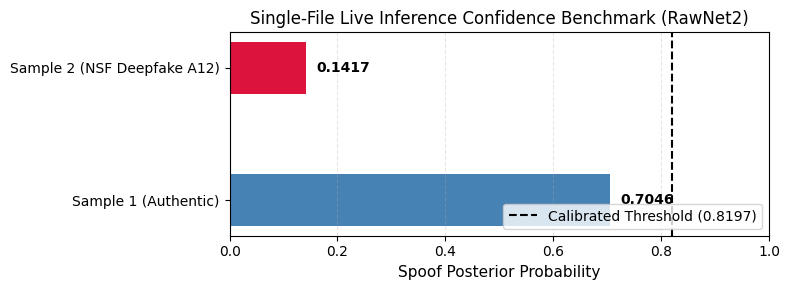

Saved Figure 16: Single-file live inference verification.


In [26]:
def predict_raw_audio(file_path, net, decision_threshold):
    net.eval()
    sig = read_raw_waveform(file_path, target_len=64000)
    tensor_in = torch.from_numpy(sig).float().unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            prob = torch.softmax(net(tensor_in), dim=1)[0, 1].item()

    is_detected_spoof = prob >= decision_threshold
    decision = "SPOOF (SYNTHETIC VOICE DETECTED)" if is_detected_spoof else "BONAFIDE (AUTHENTIC HUMAN VOICE)"
    confidence = prob if is_detected_spoof else (1.0 - prob)

    return {
        "file_name": os.path.basename(file_path),
        "decision": decision,
        "spoof_probability": round(prob, 5),
        "confidence": f"{confidence * 100:.2f}%",
        "operating_threshold": round(decision_threshold, 4)
    }

demo_bon_path = eval_df_scored[eval_df_scored["key"] == "bonafide"].iloc[1]["file_path"]
demo_spf_path = eval_df_scored[eval_df_scored["attack_id"] == "A12"].iloc[1]["file_path"]

print("Live File-Level Biometric Inference Demonstration:")
print("")
print("--- Test Sample 1: Ground Truth Authentic ---")
res_bon = predict_raw_audio(demo_bon_path, model, optimal_threshold)
print(json.dumps(res_bon, indent=2))

print("")
print("--- Test Sample 2: Ground Truth Deepfake (A12 Neural Source-Filter) ---")
res_spf = predict_raw_audio(demo_spf_path, model, optimal_threshold)
print(json.dumps(res_spf, indent=2))

fig, ax = plt.subplots(figsize=(8, 3))
test_names = ["Sample 1 (Authentic)", "Sample 2 (NSF Deepfake A12)"]
test_probs = [res_bon["spoof_probability"], res_spf["spoof_probability"]]
test_colors = ["steelblue", "crimson"]

bars = ax.barh(test_names, test_probs, color=test_colors, height=0.4)
ax.axvline(optimal_threshold, color="black", linestyle="--", lw=1.5, label=f"Calibrated Threshold ({optimal_threshold:.4f})")
ax.set_xlim(0, 1.0)
ax.set_xlabel("Spoof Posterior Probability", fontsize=11)
ax.set_title("Single-File Live Inference Confidence Benchmark (RawNet2)", fontsize=12)
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis="x", linestyle="--", alpha=0.3)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.02, bar.get_y() + bar.get_height()/2.0, f"{w:.4f}", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "16_single_file_live_inference_verification.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved Figure 16: Single-file live inference verification.")


In [27]:
final_summary_report = {
    "study_metadata": {
        "model_architecture": "RawNet2-Mini (SincNet + Feature Map Scaling FMS)",
        "front_end_features": "Raw 1D Audio Waveform (64,000 samples @ 16 kHz)",
        "input_tensor_shape": [1, 1, 64000],
        "dataset_benchmark": "ASVspoof 2019 Logical Access",
        "training_epochs": epochs,
        "batch_size": batch_size,
        "loss_function": "Focal Loss (alpha=0.75, gamma=2.0, label_smoothing=0.05)",
        "optimizer": "AdamW (lr=1e-4, weight_decay=1e-4) with Cosine Annealing"
    },
    "development_partition_results": {
        "eer_percent": round(dev_metrics["eer"] * 100, 3),
        "normalized_min_tdcf": round(dev_metrics["min_tdcf"], 4),
        "roc_auc": round(dev_metrics["auc"], 4),
        "calibrated_decision_threshold": round(optimal_threshold, 4),
        "total_utterances": len(dev_targets)
    },
    "evaluation_partition_results": {
        "eer_percent": round(eval_metrics["eer"] * 100, 3),
        "normalized_min_tdcf": round(eval_metrics["min_tdcf"], 4),
        "roc_auc": round(eval_metrics["auc"], 4),
        "overall_accuracy_percent": round(acc_eval * 100, 2),
        "overall_f1_score": round(f1_eval_val, 4),
        "total_utterances": len(eval_targets)
    }
}

report_json_path = "/kaggle/working/experiment_final_report.json"
with open(report_json_path, "w", encoding="utf-8") as f:
    json.dump(final_summary_report, f, indent=2)

print("")
print("=" * 80)
print("FINAL ARTIFACT INVENTORY AND VERIFICATION")
print("=" * 80)
print(f"1. Checkpoint:         {best_model_path}")
print(f"2. Training History:   {history_file}")
print(f"3. Final Report JSON:  {report_json_path}")
print(f"4. Attack Breakdown:   {csv_out_path}")
print("5. Diagnostic Figures in /kaggle/working/figures/:")
for fig_file in sorted(os.listdir(fig_dir)):
    sz = os.path.getsize(os.path.join(fig_dir, fig_file))
    print(f"   - {fig_file} ({sz/1024:.1f} KB)")
print("=" * 80)
print("RawNet2 End-to-End research study completed successfully.")



FINAL ARTIFACT INVENTORY AND VERIFICATION
1. Checkpoint:         /kaggle/working/models/rawnet2_best.pth
2. Training History:   /kaggle/working/models/training_history.json
3. Final Report JSON:  /kaggle/working/experiment_final_report.json
4. Attack Breakdown:   /kaggle/working/attack_vulnerability_breakdown.csv
5. Diagnostic Figures in /kaggle/working/figures/:
   - 01_class_distribution_breakdown.png (186.1 KB)
   - 02_attack_distribution_analysis.png (187.3 KB)
   - 03_audio_duration_length_distribution.png (174.1 KB)
   - 04_waveform_time_domain_glottal_inspection.png (863.5 KB)
   - 05_sincnet_learned_filterbank_frequency_response.png (474.1 KB)
   - 06_instantaneous_energy_envelope_detection.png (473.1 KB)
   - 07_time_domain_signal_preprocessing_pipeline.png (761.6 KB)
   - 08_training_loss_and_dev_eer_trajectories.png (250.5 KB)
   - 09_receiver_operating_characteristic_roc.png (218.1 KB)
   - 10_detection_error_tradeoff_det.png (157.2 KB)
   - 11_precision_recall_curves.png 